# Current and Future Constraints on the Primordial Power Spectrum

This notebook reproduces the figures and tables of Cheslog, Finson, MacInnis, Sehgal, Afshordi, Nerval, and Hlo$\hat{\mathrm{z}}$ek. (2026),
*"Current and Future Constraints on the Primordial Power Spectrum"*.

It is organized in two parts:

* **Part 1: Current results** reproduces the current-data constraints:
  Figure 1 and the current-constraints table, from the (thinned) MCMC
  chains, along with the marginalized binned-$\mathcal{P}(k)$ chain
  statistics used by the later figures.
* **Part 2: Forecasted results** reproduces the remaining figures and
  tables (Figures 2 through 11), from the saved Fisher matrices, the saved
  Figure 6 points, and the chains and statistics loaded in Part 1.

**Data products.** Everything this notebook loads lives in the
`hdinitpk/data/` directory that ships with the `hdinitpk` package, located
below with `hdinitpk.data_path`. Its contents were precomputed
from the raw chains and Fisher derivative outputs: every Fisher matrix
(saved with `save_fisher_matrix`, with the priors and DESI BAO Fisher
already applied), the Figure 6 $P_\mathrm{lin}(k, z=0)$ points,
getdist-thinned copies of the MCMC chains, the binned-$\mathcal{P}(k)$
chain statistics, and the small binning files the figures need.

**Requirements:** `hdfisher`, `hdinitpk` (its `plotting_utilities` module
provides the colors, labels, and figure/table helpers used below; its
Fisher code produced the saved binned-$\mathcal{P}(k)$ Fisher matrices),
`hd_mock_data`, `hd_pk`, `getdist`, `numpy`, `pandas`, and `matplotlib`.

The cells are meant to be executed in order from top to bottom.

## Imports and plot style

In [1]:
import os
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

from getdist import mcsamples, plots
from getdist.gaussian_mixtures import GaussianND

from hdfisher import utils, fisher
from hd_mock_data import hd_data
from hd_pk import cmb_from_pk

import hdinitpk
from hdinitpk import plotting_utilities
from hdinitpk.plotting_utilities import (
    ratio, print_table, sigfig, getdist_samples, legend_below, set_loglog,
    add_box_errors, param_labels, err_sig_figs, ratio_decimals,
    cb_orange, cb_skyblue, cb_blue, cb_vermillion, cb_pink,
    red, green, darkyellow, magenta, brightblue, blue,
    fig1_colors, exp_colors, exp_labels,
    mpk_labels, mpk_colors, mpk_zorders, param_line_kwargs, flat_legend)

%matplotlib inline

--------------------------------------------------------------------------
but there are no active ports detected (or Open MPI was unable to use
them).  This is most certainly not what you wanted.  Check your
cables, subnet manager configuration, etc.  The openib BTL will be
ignored for this job.

  Local host: login1
--------------------------------------------------------------------------


In [2]:
# apply the matplotlib style (rcParams) from plotting_utilities:
plotting_utilities.set_plot_style()


## Configuration

All file locations and global analysis choices are set here. The only
input location is `notebook_data_path`, the `hdinitpk/data/` directory that
ships with the package (the two large products needed for the bias
calculation are located in that section below, under
`hdinitpk.external_data_path`).

In [3]:
# Location of the data products used by this notebook. Everything the
# notebook loads lives in the `hdinitpk/data` directory that ships with the
# `hdinitpk` package, resolved here with `hdinitpk.data_path` so that the
# notebook runs from any working directory. Set the `HDINITPK_DATA`
# environment variable to point it at a copy elsewhere.
notebook_data_path = hdinitpk.DATA_DIR
fisher_matrix_path = hdinitpk.data_path('fisher_matrices')
chains_data_path = hdinitpk.data_path('chains')
fig6_data_path = hdinitpk.data_path('fig6')
cache_path = hdinitpk.data_path('cached_results')
binning_data_path = hdinitpk.data_path('binning')
print(f'loading data products from {notebook_data_path}')

# CMB-HD mock data version and the corresponding binning library (used in
# the bias-calculation section):
data_version = 'v1.1'
hd_datalib = hd_data.HDMockData(version=data_version)

# Fiducial optical depth, used wherever an explicit e^{-2 tau} factor is
# applied to the primordial power spectrum.
tau = 0.0544

# Figure saving. When True, every figure below is written to the current
# working directory as `fig<N>-<month>-<day>-<year>.png`, using the date on
# which the notebook is run (for example `fig1-july-26-2026.png`). Set to
# False to display the figures without writing any files.
save_figures = False


def save_figure(fig_name, **savefig_kwargs):
    """Save the current figure via `plotting_utilities.save_figure`, but
    only if the `save_figures` flag above is True."""
    plotting_utilities.save_figure(fig_name, enabled=save_figures,
                                   **savefig_kwargs)

loading data products from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/hdinitpk/data


In [4]:
# Parameter sets used throughout. The naming convention follows CAMB
# (see the CAMB <-> CLASS translation section below for the CLASS names).
nine_params = ['mnu', 'tau', 'logA', 'H0', 'ombh2', 'omch2', 'ns', 'nnu', 'nrun']
eight_params = ['mnu', 'tau', 'logA', 'H0', 'ombh2', 'omch2', 'ns', 'nnu']
six_params = ['tau', 'logA', 'H0', 'ombh2', 'omch2', 'ns',]
feedback_params = nine_params + ['HMCode_logT_AGN', 'n_ksz', 'A_ksz']

## Helper functions

The figure and table helpers (`ratio`, `print_table`, `sigfig`,
`getdist_samples`, `legend_below`, `set_loglog`, `add_box_errors`) were
imported from `hdinitpk.plotting_utilities` above. The helpers below load
the data products from the data directory.

In [5]:
def load_saved_fisher(name):
    """Load a saved Fisher matrix from the packaged data directory. Returns
    the `(fisher_matrix, params)` pair, exactly as `Fisher.get_fisher`
    would; the tau prior (and, where applicable, the DESI BAO Fisher and the
    HMCode_logT_AGN prior) are already applied. The `hd_class_*` and
    `hd_ext_*` files keep native CLASS parameter names; translate those
    with `from_class_fisher` / `from_class_errors` (defined below) at load
    time."""
    return fisher.load_fisher_matrix(
        os.path.join(fisher_matrix_path, f'{name}.txt'))


def load_saved_results(name):
    """Read a saved results file from `<data>/cached_results`: one row per
    quantity, with the name followed by its values."""
    fname = os.path.join(cache_path, f'{name}.txt')
    results = {}
    with open(fname, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip():
                continue
            key, *values = line.split()
            results[key] = [float(v) for v in values]
    print(f"loaded '{name}' from {fname}")
    return results


def find_chain_root(name):
    """Locate the getdist root of a thinned chain by name. The chains
    directory may be organized into subdirectories (`pas/`, `P-ACT-LB/`,
    `hd/`, `binned_pk/`), so look for `<chains>/<name>` first and then one
    level down."""
    candidates = [os.path.join(chains_data_path, name)]
    if os.path.isdir(chains_data_path):
        candidates += [os.path.join(chains_data_path, sub, name)
                       for sub in sorted(os.listdir(chains_data_path))
                       if os.path.isdir(os.path.join(chains_data_path, sub))]
    for root in candidates:
        # a getdist root is <root>.paramnames alongside <root>.txt or
        # <root>.N.txt
        if os.path.exists(f'{root}.paramnames') or os.path.exists(f'{root}.txt'):
            return root
    raise FileNotFoundError(
        f"could not find the thinned chain '{name}' under {chains_data_path}. "
        f"Looked for: {candidates}")


def load_thinned_chain(name):
    """Load a saved, thinned MCMC chain from `<data>/chains`. The burn-in
    (`ignore_rows = 0.5`) was removed *before* thinning and saving, so
    `ignore_rows` must stay 0 here (removing it again would silently
    discard half of the remaining samples)."""
    return mcsamples.loadMCSamples(find_chain_root(name),
                                   settings={'ignore_rows': 0})


# Gelman-Rubin R-1 of each full chain, recorded before the chains were
# thinned (it cannot be recomputed from a merged thinned chain):
chain_convergence = {}
with open(os.path.join(chains_data_path, 'chain_convergence.txt'), 'r') as f:
    for line in f:
        if line.startswith('#') or not line.strip():
            continue
        key, val = line.split()
        chain_convergence[key] = float(val)

## CAMB <-> CLASS parameter-name translation

The CLASS Fisher matrices (`hd_class_*` and `hd_ext_*`) are saved with their original CLASS parameter names. We translate them to CAMB paramater names when they are loaded in for ease of use.

In [6]:
# NOTE: deliberately named `*_fisher_params` so it does not interfere with the
# `camb_to_class_chain_params` defined in the Figure 9 section for the MCMC
# chain columns -- those are chain column names ('N_eff'), which are not the
# same as the Fisher parameter names ('Neff').
camb_to_class_fisher_params = {
    'ombh2': 'omega_b',
    'omch2': 'omega_cdm',
    'theta': 'theta_s_100',
    'tau':   'tau_reio',
    'logA':  'ln_A_s_1e10',
    'As':    'A_s',
    'ns':    'n_s',
    'H0':    'H0',
    'nnu':   'Neff',
    # `sum_m_ncdm` is the TOTAL mass, the same quantity as CAMB's `mnu`.
    # `m_ncdm` (per-species) is what CLASS receives, but it is built inside
    # `set_class_params` and is never a varied parameter.
    'mnu':   'sum_m_ncdm',
    'nrun':  'alpha_s',
    'omk':   'Omega_k',
    'w':     'w0_fld',
    'wa':    'wa_fld',
    'HMCode_logT_AGN': 'log10T_heat_hmcode',
}
class_to_camb_fisher_params = {v: k for k, v in camb_to_class_fisher_params.items()}
# accept the convenience spelling too, in case a Fisher was built from a
# parameter file that varied `Neff` rather than `N_ur`:
class_to_camb_fisher_params['Neff'] = 'nnu'


def to_class(params):
    """CAMB parameter names -> CLASS names, for passing INTO a CLASS Fisher.
    Accepts a list of names or a dict keyed by name (e.g. `priors`)."""
    if isinstance(params, dict):
        return {camb_to_class_fisher_params.get(p, p): v for p, v in params.items()}
    return [camb_to_class_fisher_params.get(p, p) for p in params]


def from_class_errors(errors):
    """`get_fisher_errors` output -> CAMB names."""
    return {class_to_camb_fisher_params.get(p, p): v for p, v in errors.items()}


def from_class_fisher(result):
    """`get_fisher` output -> CAMB names. Only the parameter names change;
    every varied CLASS parameter is the same quantity as its CAMB
    counterpart, so the matrix itself is untouched."""
    matrix, params = result
    return matrix, [class_to_camb_fisher_params.get(p, p) for p in params]


def from_class_derivs(result):
    """`load_cmb_fisher_derivs` output -> CAMB names. The derivatives
    themselves are unchanged."""
    ells, derivs = result
    out = {}
    for cmb_type, per_param in derivs.items():
        out[cmb_type] = {class_to_camb_fisher_params.get(p, p): spectra
                         for p, spectra in per_param.items()}
    return ells, out


def check_class_names(fisherlib, params):
    """Raise if a translated name is not a varied parameter of
    `fisherlib`, instead of failing later with a bare KeyError inside
    `calc_cmb_fisher`."""
    wanted = to_class(params)
    missing = [p for p in wanted if p not in fisherlib.fisher_params]
    if missing:
        raise KeyError(
            f"these CLASS parameter names are not in the Fisher: {missing}.\n"
            f"  requested : {wanted}\n"
            f"  available : {sorted(fisherlib.fisher_params)}\n"
            "Fix `camb_to_class_fisher_params` above to match the names in your "
            "CLASS parameter and step-size files.")
    return wanted

# Part 1: Current results

Everything in this part comes from the MCMC chains run on current data:
the CMB-PAS + DESI DR2 chains for the four cosmological models, the
P-ACT-LB comparison chain, and the binned-$\mathcal{P}(k)$ chains. The
chains were thinned with getdist (`MCSamples.weighted_thin`) before being
saved; the marginalized binned-$\mathcal{P}(k)$ statistics were computed
from the full, un-thinned chains.

## MCMC chains for the current constraints

Load the (thinned) CMB-PAS + DESI DR2 chains for the four cosmological
models, and the P-ACT-LB comparison chain. These are used for Figures 1, 2,
and 4 and for the current-constraints table. The quoted R-1 values were
computed from the full chains before thinning.

In [9]:
chain_models = ['lcdm_nrun', 'w0wacdm_nrun', 'lcdm_nrun_nnu', 'lcdm_nrun_nnu_mnu']

# `samples` holds the distributions plotted in Figures 2 and 4, keyed first by
# data set ('spa' for the CMB-PAS + DESI chains; 'so' and 'hd' Fisher
# forecasts are added below) and then by cosmological model.
samples = {'spa': {}}
mcmc_means = {}
for param_model in chain_models:
    chain = load_thinned_chain(f'spa_{param_model}')
    chain.paramNames.parWithName('nrun').label = r'\alpha_\mathrm{s}'
    cosmomc_theta = chain.getParams().cosmomc_theta
    chain.addDerived(100 * cosmomc_theta, 'theta', label=r'100\theta_\mathrm{MC}')
    samples['spa'][param_model] = chain

    mcmc_means[param_model] = {}
    mstats = chain.getMargeStats()
    for param in mstats.list():
        mcmc_means[param_model][param] = mstats.parWithName(param).mean

    r_minus_1 = chain_convergence.get(f'spa_{param_model}', float('nan'))
    print(f'{param_model:22s} : R-1 = {r_minus_1:7.4f} (full chain)')

# Center the Fisher forecast contours (Figures 2 and 4) on the marginalized
# means of the 9-parameter chain.
mcmc_fid_params = mcmc_means['lcdm_nrun_nnu_mnu'].copy()



lcdm_nrun              : R-1 =  0.0045 (full chain)
w0wacdm_nrun           : R-1 =  0.0051 (full chain)
lcdm_nrun_nnu          : R-1 =  0.0051 (full chain)
lcdm_nrun_nnu_mnu      : R-1 =  0.0053 (full chain)


## Inflation model predictions

Predictions for $n_\mathrm{s}$ and $\alpha_\mathrm{s}$ from the early
Universe models discussed in the paper. Models with a range of predictions
are evaluated at the endpoints of the assumed range of e-folds
($N_* \in [47, 57]$) or of $\theta_*/l_p$.

In [10]:
monodromy = {'nrun': np.zeros(2), 'ns': np.zeros(2)}
SBSGUT = {'nrun': np.zeros(2), 'ns': np.zeros(2)}
QQG = {'nrun': np.zeros(2), 'ns': np.zeros(2)}
poly = {'nrun': np.zeros(2), 'ns': np.zeros(2)}
for i, N_star in enumerate(np.linspace(47, 57, 2)):
    QQG['nrun'][i] = -4 / (3 * (N_star**2))
    QQG['ns'][i] = 1 - (4 / (3 * N_star))
    monodromy['nrun'][i] = -6 / (5 * N_star**2)
    monodromy['ns'][i] = 1 - (6 / (5 * N_star))
    SBSGUT['nrun'][i] = -1 / (N_star**2)
    SBSGUT['ns'][i] = 1 - (1 / N_star)
    poly['ns'][i] = 1 - (2 / N_star) * (3 / 4)
    poly['nrun'][i] = -(2 / N_star**2) * (3 / 4)

rhc_theta_star_lp_vals = np.linspace(0.1, 10, 2)
inflation_models = {
    'starobinsky': {'ns': [1 - 2/50, 1 - 2/60], 'nrun': [-2/(50**2), -2/(60**2)]},
    'bithermal': {'ns': [0.96478], 'nrun': [-1.8e-3]},
    'rhc': {'ns': [1 - (1 / (32.17 + np.log(theta_star_lp)))
                   for theta_star_lp in rhc_theta_star_lp_vals],
            'nrun': [1 / ((32.17 + np.log(theta_star_lp))**2)
                     for theta_star_lp in rhc_theta_star_lp_vals]},
    'qqg': QQG.copy(),
    'sbs': SBSGUT.copy(),
    'mono': monodromy.copy(),
    'poly': poly.copy(),
}

In [11]:
# Styling for Figure 1 (and reused for the inflation models in Figure 2).
data_label = 'CMB-PAS + DESI DR2'
model_labels = {
    'lcdm_nrun': r'$\Lambda$CDM+$\alpha_\mathrm{s}$',
    'w0wacdm_nrun': r'$w_0 w_a$CDM+$\alpha_\mathrm{s}$',
    'lcdm_nrun_nnu': r'$\Lambda$CDM+$\alpha_\mathrm{s}$+$N_\mathrm{eff}$',
    'lcdm_nrun_nnu_mnu': r'$\Lambda$CDM+$\alpha_\mathrm{s}$+$N_\mathrm{eff}$+$\sum m_\nu$',
}

fig1_param_models = chain_models
plt_inflation_models = ['bithermal', 'starobinsky', 'mono', 'rhc', 'qqg', 'sbs', 'poly']

# settings for the data contours:
contour_lw = 1.05
contour_alpha = 0.8




# `fig1_colors` (one color per cosmological model) is imported from
# `hdinitpk.plotting_utilities`.
fig1_kwargs = {param_model: {'color': fig1_colors[param_model],
                             'lw': contour_lw,
                             'label': model_labels[param_model]}
               for param_model in fig1_param_models}

# the colorblind-friendly palette (cb_orange, cb_skyblue, cb_blue,
# cb_vermillion, cb_pink) is imported from `hdinitpk.plotting_utilities`.
inflation_models_markersize = 6
inflation_models_lw = 1.5

inflation_models['starobinsky']['kwargs'] = {
    'label': r'Starobinsky$\, / \,$Higgs$\, / \,$Exp. $\alpha$-attractor',
    'zorder': 3, 'ls': '-', 'lw': inflation_models_lw,
    'marker': 'p', 'markersize': inflation_models_markersize,
    'color': cb_blue}
inflation_models['bithermal']['kwargs'] = {
    'label': 'Bi-thermal', 'ls': 'none',
    'marker': '*', 'markersize': 10, 'color': cb_skyblue}
inflation_models['rhc']['kwargs'] = {
    'label': 'Renorm. Holo. Cosmo.', 'ls': '-', 'lw': inflation_models_lw,
    'marker': 'D', 'markersize': inflation_models_markersize,
    'zorder': 3, 'color': cb_vermillion}
inflation_models['qqg']['kwargs'] = {
    'label': 'Quant. Quad. Grav.', 'zorder': 3,
    'ls': '-', 'lw': inflation_models_lw,
    'marker': 's', 'markersize': inflation_models_markersize,
    'color': cb_orange}
inflation_models['mono']['kwargs'] = {
    'label': r'Axion-monodromy$\, / \,$$V(\phi) \propto \phi^n, n=2/5$',
    'zorder': 5, 'ls': '-', 'lw': inflation_models_lw,
    'marker': '^', 'markersize': inflation_models_markersize,
    'color': 'tab:green'}
inflation_models['sbs']['kwargs'] = {
    'label': 'SUSY GUTS', 'zorder': 4,
    'ls': '-', 'lw': inflation_models_lw,
    'marker': 'o', 'markersize': inflation_models_markersize,
    'color': cb_pink}
inflation_models['poly']['kwargs'] = {
    'label': r'Poly. $\alpha$-attractor ($\kappa = 2$)', 'zorder': 5,
    'ls': '-', 'lw': inflation_models_lw,
    'marker': 'v', 'markersize': inflation_models_markersize,
    'color': 'dimgray'}

# `param_line_kwargs` (the nrun = 0 / ns = 1 guide lines) and
# `flat_legend` are imported from `hdinitpk.plotting_utilities`.


# Figure 1

Current constraints on ($n_\mathrm{s}$, $\alpha_\mathrm{s}$) from
CMB-PAS + DESI DR2 for the four cosmological models, compared to the
inflation model predictions.

saved /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/fig1-august-26-2026.png


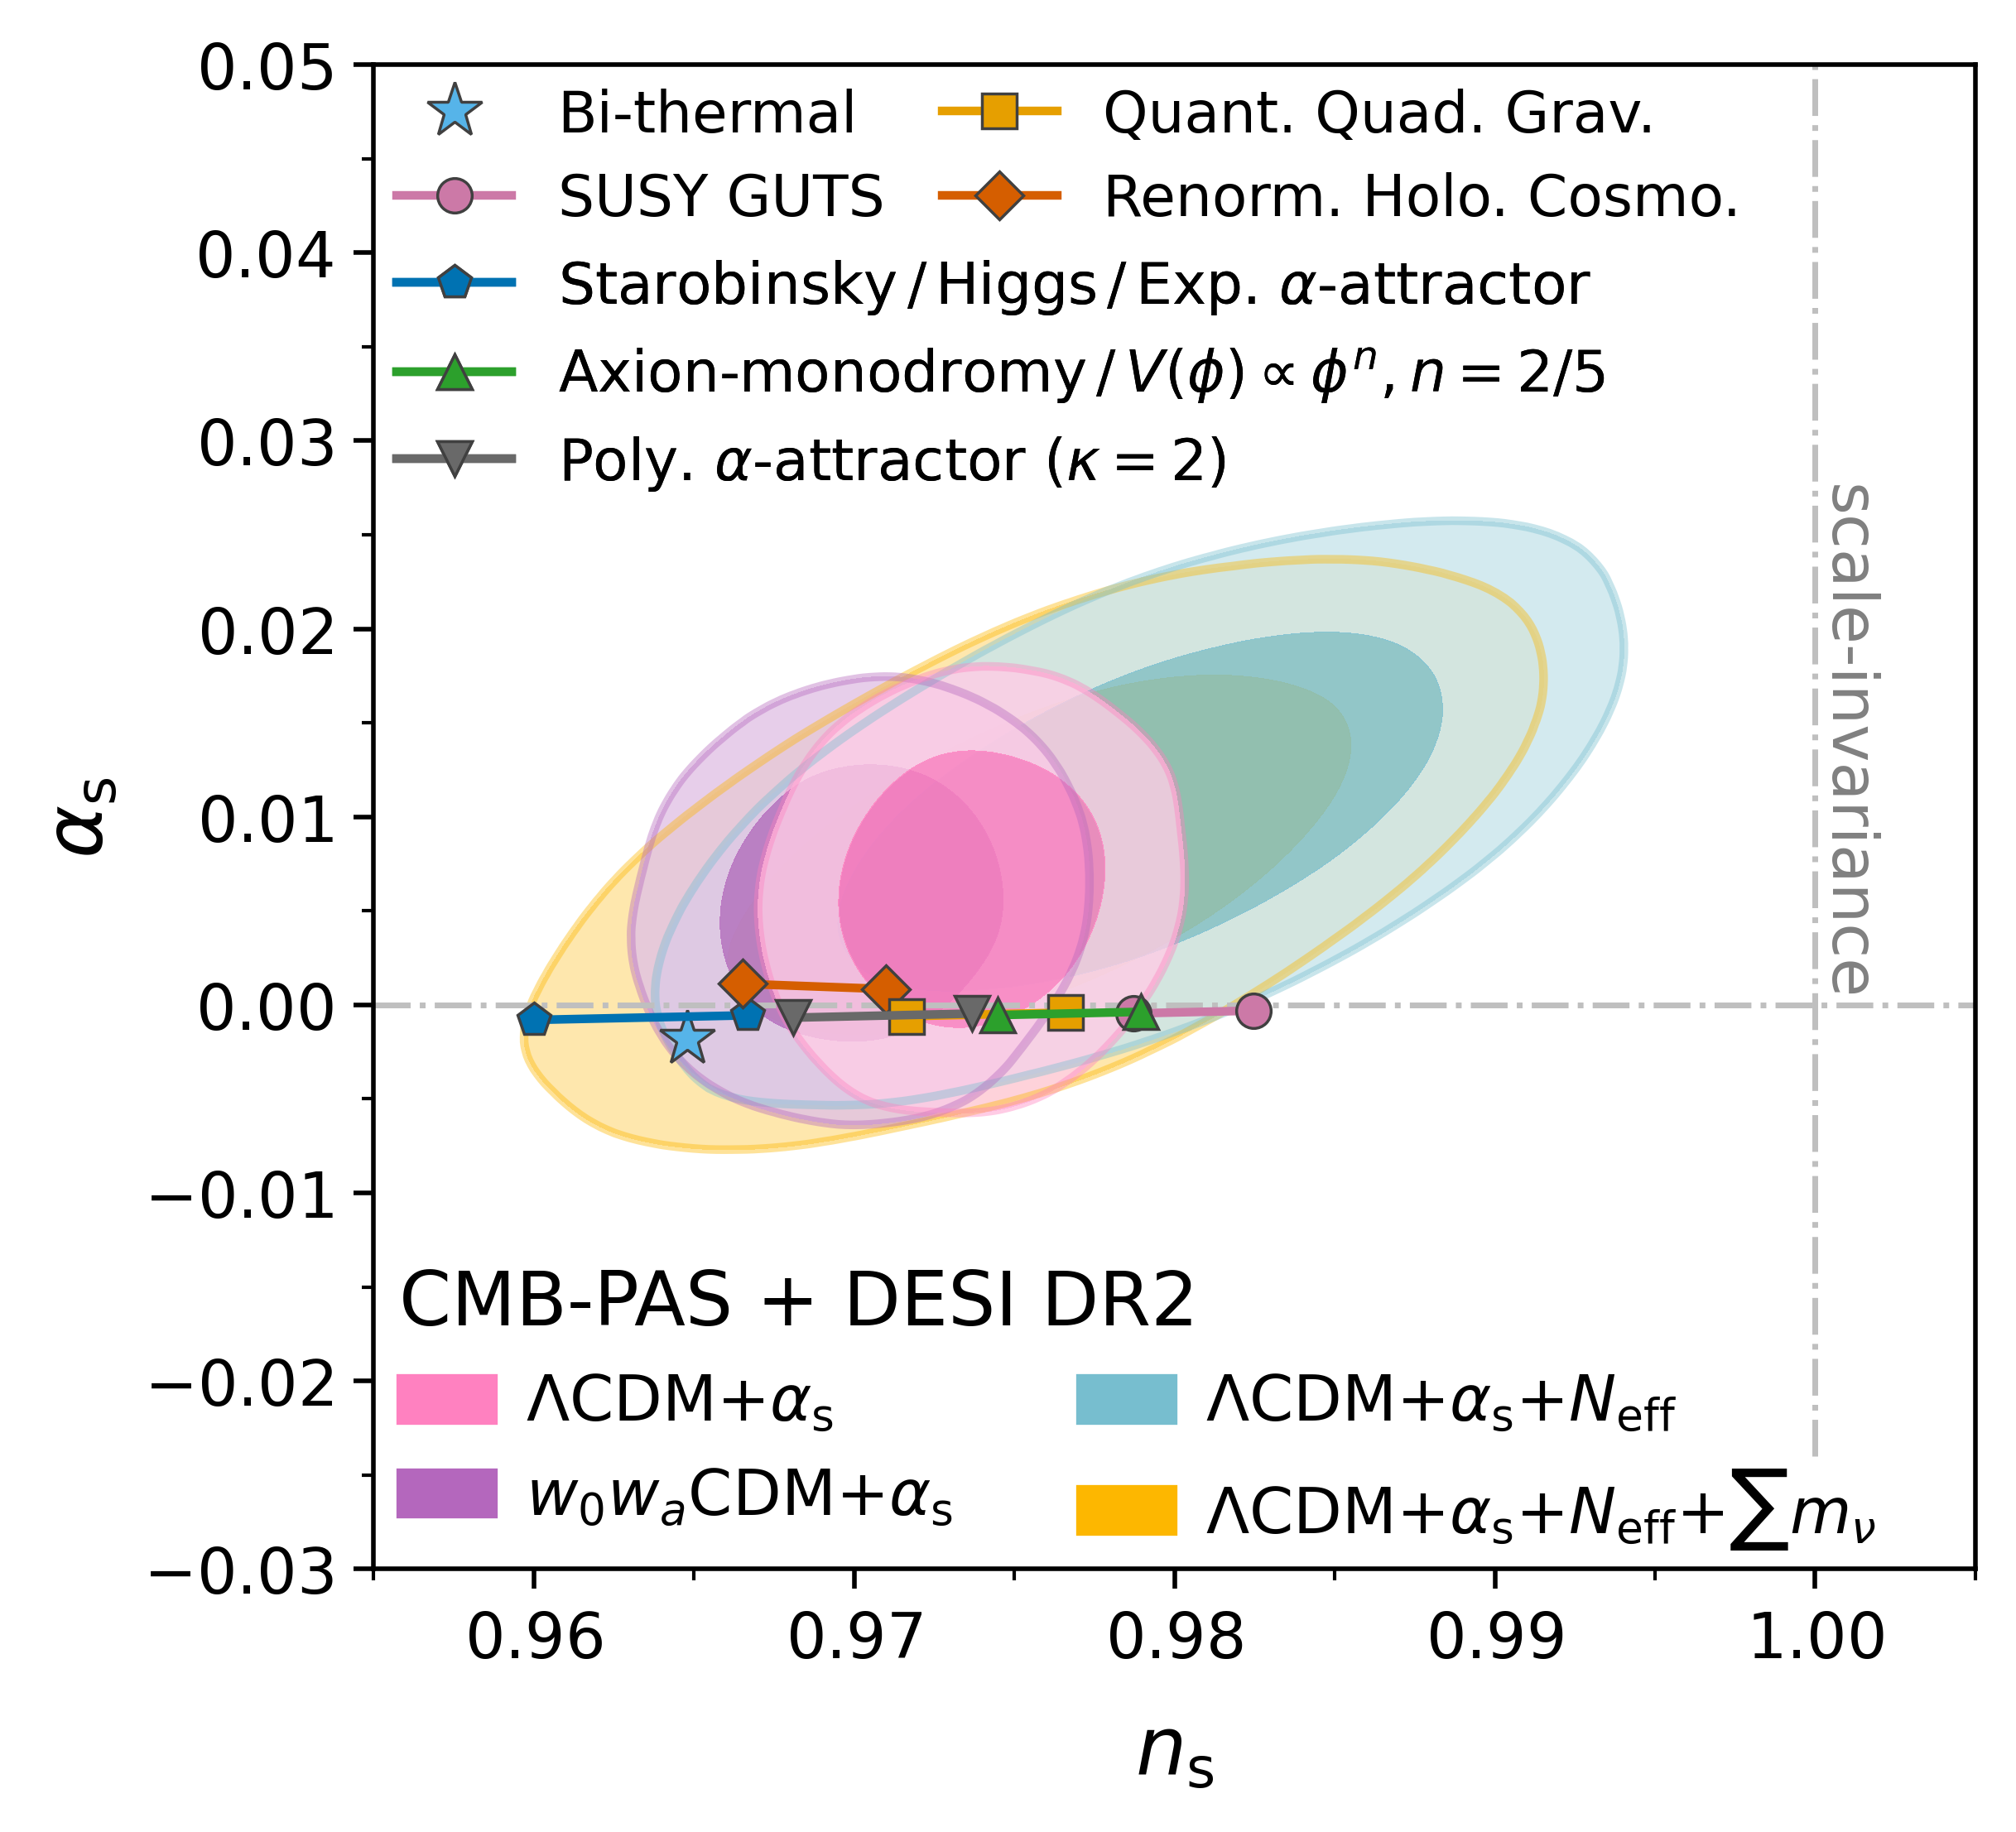

In [12]:
gd_fig = plots.get_subplot_plotter(subplot_size=5, subplot_size_ratio=0.9)

# plot the data in reverse order (largest contour first):
plt_samples = [samples['spa'][param_model] for param_model in fig1_param_models[::-1]]
colors = [fig1_kwargs[param_model]['color'] for param_model in fig1_param_models[::-1]]
lws = [contour_lw] * len(plt_samples)
gd_fig.plot_2d(plt_samples, ['ns', 'nrun'], colors=colors, filled=True,
               lws=lws, contour_args={'alpha': contour_alpha})

ax = gd_fig.subplots[0, 0]

# add a legend for the data contours:
data_handles = [mpatches.Patch(**fig1_kwargs[param_model])
                for param_model in fig1_param_models]
legend = ax.legend(handles=data_handles, fontsize=11, title=data_label,
                   title_fontsize=13, alignment='left', ncol=2,
                   bbox_to_anchor=(0, -0.005), loc='lower left',
                   handlelength=1.5, handletextpad=0.5, **flat_legend)
ax.add_artist(legend)

# plot the inflation models, keeping handles keyed by model name:
model_handles = {}
for imodel in plt_inflation_models:
    model_handle, = ax.plot(inflation_models[imodel]['ns'],
                            inflation_models[imodel]['nrun'],
                            markeredgecolor='0.25', markeredgewidth=0.5,
                            **inflation_models[imodel]['kwargs'])
    model_handles[imodel] = model_handle

# two legend groups for the models, stacked top to bottom:
top_handles = [model_handles['bithermal'], model_handles['sbs'],
               model_handles['qqg'], model_handles['rhc']]      # 2 columns
mid_handles = [model_handles['starobinsky'], model_handles['mono'],
               model_handles['poly']]                           # 1 column

legend_top = ax.legend(handles=top_handles, fontsize=10, columnspacing=1,
                       bbox_to_anchor=(0, 1), loc='upper left', ncol=2,
                       **flat_legend)
ax.add_artist(legend_top)
legend_mid = legend_below(ax, legend_top, mid_handles, ncol=1, **flat_legend)

# line for zero running (nrun = 0):
ax.axhline(**param_line_kwargs)
# line for scale-invariance (ns = 1); the range in y is set explicitly so the
# line does not run through the legend labels:
ax.vlines(1.0, -0.024, 0.05, **param_line_kwargs)
ax.text(1.000, 0.001, 'scale-invariance', fontsize=11, rotation=270,
        rotation_mode='default', color='0.5',
        verticalalignment='baseline', horizontalalignment='left')

ax.set_xlim(0.955, 1.005)
ax.set_ylim(-0.030, 0.05)
ax.xaxis.set_major_locator(MultipleLocator(0.01))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.yaxis.set_minor_locator(MultipleLocator(0.005))

save_figure('fig1')
plt.show()

## Current-constraints table

LaTeX body for the current-constraints table. All five
columns are computed directly from getdist MCMC chains: the P-ACT-LB
($\Lambda$CDM+$\alpha_s$) column is loaded here from its own (thinned) chain, and the
four CMB-PAS + DESI DR2 columns come from the chains loaded above.

Errors are getdist's marginalized standard deviation (`par.err`), used here
as the 1-sigma. Swap `mean_pm` to use (upper - lower)/2 from `par.limits`.

In [13]:
# load the (thinned) P-ACT-LB (LCDM + alpha_s) chain for the comparison column
pact_lb_nrun_samples = load_thinned_chain('pact_lb_nrun')
if pact_lb_nrun_samples.paramNames.parWithName('nrun') is not None:
    pact_lb_nrun_samples.paramNames.parWithName('nrun').label = r'\alpha_\mathrm{s}'
print(f"{'p-act-lb (lcdm_nrun)':24s} : R-1 = "
      f"{chain_convergence.get('pact_lb_nrun', float('nan')):7.4f} (full chain)")

# columns in table order: P-ACT-LB first, then the four CMB-PAS + DESI columns
table_columns = [('pact_lb', pact_lb_nrun_samples)]
table_columns += [(m, samples['spa'][m]) for m in chain_models]

# make sure the 100*theta_MC derived parameter exists in every chain
for _, chain in table_columns:
    if chain.paramNames.parWithName('theta') is None:
        cosmomc_theta = chain.getParams().cosmomc_theta
        chain.addDerived(100 * cosmomc_theta, 'theta', label=r'100\theta_\mathrm{MC}')

# cache marge stats per column
column_stats = {key: chain.getMargeStats() for key, chain in table_columns}
column_keys = [key for key, _ in table_columns]


def first_present(stats, candidates):
    """First candidate parameter name present (and varying) in `stats`,
    else None."""
    for c in candidates:
        par = stats.parWithName(c)
        if par is not None and par.err != 0:
            return c
    return None


def mean_pm(stats, candidates, dec):
    r"""'mean $\pm$ err' to `dec` decimals, or '---' if the parameter is
    absent or fixed."""
    name = first_present(stats, candidates)
    if name is None:
        return '---'
    par = stats.parWithName(name)
    return f'{par.mean:.{dec}f} $\\pm$ {par.err:.{dec}f}'


def upper_limit(stats, candidates, dec, level=0.95):
    r"""'$<$ x' upper limit at `level` to `dec` decimals, or '---' if
    absent."""
    name = first_present(stats, candidates)
    if name is None:
        return '---'
    par = stats.parWithName(name)
    # par.limits is aligned with stats.limits (the requested contour levels)
    i = min(range(len(stats.limits)), key=lambda k: abs(stats.limits[k] - level))
    return f'$<$ {par.limits[i].upper:.{dec}f}'


# per-row spec: (chain-name candidates, latex label, decimals, kind), where
# 'pm' -> mean +/- err ; 'upper' -> upper limit ; 'rule' -> internal \midrule
TABLE_ROWS = [
    (('ombh2', 'omegabh2'),     r'$\Omega_\mathrm{b} h^2$',     5, 'pm'),
    (('omch2', 'omegach2'),     r'$\Omega_\mathrm{c} h^2$',     4, 'pm'),
    (('theta', 'theta_MC_100'), r'$100 \theta_\mathrm{MC}$',    5, 'pm'),
    (('tau', 'tau_reio'),       r'$\tau$',                      4, 'pm'),
    (('logA',),                 r'$\ln(10^{10} A_\mathrm{s})$', 3, 'pm'),
    (('ns',),                   r'$n_\mathrm{s}$',              4, 'pm'),
    (('nrun',),                 r'$\alpha_\mathrm{s}$',         4, 'pm'),
    (('w', 'w0'),               r'$w_0$',                       3, 'pm'),
    (('wa',),                   r'$w_a$',                       2, 'pm'),
    (('nnu', 'N_eff'),          r'$N_\mathrm{eff}$',            2, 'pm'),
    (('mnu',),                  r'$\sum m_\nu$ [eV]',           3, 'upper'),
    (None,                      None,                           0, 'rule'),
    (('H0',),                   r'$H_0$',                       2, 'pm'),
    (('sigma8',),               r'$\sigma_8$',                  4, 'pm'),
]

lines = []
for candidates, label, dec, kind in TABLE_ROWS:
    if kind == 'rule':
        lines.append(r'\midrule')
        continue
    fmt = upper_limit if kind == 'upper' else mean_pm
    cols = [fmt(column_stats[key], candidates, dec) for key in column_keys]
    lines.append(label + r' \dotfill & ' + ' & '.join(cols) + r' \\')

print('\n'.join(lines))

/gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/hdinitpk/data/chains/P-ACT-LB/pact_lb_nrun.txt
Removed no burn in
p-act-lb (lcdm_nrun)     : R-1 =  0.0045 (full chain)
$\Omega_\mathrm{b} h^2$ \dotfill & 0.02249 $\pm$ 0.00012 & 0.02240 $\pm$ 0.00010 & 0.02236 $\pm$ 0.00010 & 0.02248 $\pm$ 0.00013 & 0.02244 $\pm$ 0.00013 \\
$\Omega_\mathrm{c} h^2$ \dotfill & 0.1179 $\pm$ 0.0009 & 0.1181 $\pm$ 0.0006 & 0.1196 $\pm$ 0.0007 & 0.1203 $\pm$ 0.0023 & 0.1194 $\pm$ 0.0023 \\
$100 \theta_\mathrm{MC}$ \dotfill & 1.04087 $\pm$ 0.00025 & 1.04090 $\pm$ 0.00023 & 1.04073 $\pm$ 0.00023 & 1.04072 $\pm$ 0.00029 & 1.04080 $\pm$ 0.00030 \\
$\tau$ \dotfill & 0.0611 $\pm$ 0.0062 & 0.0611 $\pm$ 0.0051 & 0.0537 $\pm$ 0.0054 & 0.0601 $\pm$ 0.0052 & 0.0585 $\pm$ 0.0052 \\
$\ln(10^{10} A_\mathrm{s})$ \dotfill & 3.055 $\pm$ 0.012 & 3.053 $\pm$ 0.010 & 3.040 $\pm$ 0.010 & 3.055 $\pm$ 0.010 & 3.050 $\pm$ 0.010 \\
$n_\mathrm{s}$ \dotfill & 0.9741 $\pm$ 0.0033 & 0.9737 $\pm$ 0.0027 & 0.9702 $\pm$ 0.0029 & 0.9790 $

## Binned-P(k) chain statistics

Marginalized statistics of the binned-$\mathcal{P}(k)$ parameters of the
current-data chains: the three 7-bin chains (P-ACT-LB, CMB-PAS, and
CMB-PAS + DESI) and the four 30-bin chains (the same three plus the
official P-ACT-LB binned-$\mathcal{P}(k)$ chain). These were computed
from the full chains and are used by Figures 3, 10, and 11 and the
binned-P(k) table in Part 2.

In [14]:
stats_7bin = load_saved_results('binned_pk_stats_7bin')

# Statistics of the sampled e^{-2 tau} P(k) parameters:
p_act_means = stats_7bin['p_act_means']
p_act_lower_errs = stats_7bin['p_act_lower_errs']
p_act_upper_errs = stats_7bin['p_act_upper_errs']
p_act_tot_err = stats_7bin['p_act_tot_err']

pas_desi_means = stats_7bin['pas_desi_means']
pas_desi_lower_errs = stats_7bin['pas_desi_lower_errs']
pas_desi_upper_errs = stats_7bin['pas_desi_upper_errs']
pas_desi_tot_err = stats_7bin['pas_desi_tot_err']

pas_means = stats_7bin['pas_means']
pas_lower_errs = stats_7bin['pas_lower_errs']
pas_upper_errs = stats_7bin['pas_upper_errs']
pas_tot_err = stats_7bin['pas_tot_err']

p_act_asymmetric_errors = [p_act_lower_errs, p_act_upper_errs]
pas_desi_asymmetric_errors = [pas_desi_lower_errs, pas_desi_upper_errs]
pas_asymmetric_errors = [pas_lower_errs, pas_upper_errs]

# Statistics of the derived raw P(k), kept for reference:
p_act_pk_means = stats_7bin['p_act_pk_means']
p_act_pk_lower_errs = stats_7bin['p_act_pk_lower_errs']
p_act_pk_upper_errs = stats_7bin['p_act_pk_upper_errs']
p_act_pk_tot_err = stats_7bin['p_act_pk_tot_err']

pas_desi_pk_means = stats_7bin['pas_desi_pk_means']
pas_desi_pk_lower_errs = stats_7bin['pas_desi_pk_lower_errs']
pas_desi_pk_upper_errs = stats_7bin['pas_desi_pk_upper_errs']
pas_desi_pk_tot_err = stats_7bin['pas_desi_pk_tot_err']

pas_pk_means = stats_7bin['pas_pk_means']
pas_pk_lower_errs = stats_7bin['pas_pk_lower_errs']
pas_pk_upper_errs = stats_7bin['pas_pk_upper_errs']
pas_pk_tot_err = stats_7bin['pas_pk_tot_err']


loaded 'binned_pk_stats_7bin' from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/hdinitpk/data/cached_results/binned_pk_stats_7bin.txt


In [15]:
stats_30bin = load_saved_results('binned_pk_stats_30bin')

p_act_means_30bin = stats_30bin['p_act_means']
p_act_lower_errs_30bin = stats_30bin['p_act_lower_errs']
p_act_upper_errs_30bin = stats_30bin['p_act_upper_errs']

pas_desi_means_30bin = stats_30bin['pas_desi_means']
pas_desi_lower_errs_30bin = stats_30bin['pas_desi_lower_errs']
pas_desi_upper_errs_30bin = stats_30bin['pas_desi_upper_errs']

pas_means_30bin = stats_30bin['pas_means']
pas_lower_errs_30bin = stats_30bin['pas_lower_errs']
pas_upper_errs_30bin = stats_30bin['pas_upper_errs']

official_means = stats_30bin['official_means']
official_lower_errs = stats_30bin['official_lower_errs']
official_upper_errs = stats_30bin['official_upper_errs']

p_act_asymmetric_errors_30bin = [p_act_lower_errs_30bin, p_act_upper_errs_30bin]
pas_desi_asymmetric_errors_30bin = [pas_desi_lower_errs_30bin, pas_desi_upper_errs_30bin]
pas_asymmetric_errors_30bin = [pas_lower_errs_30bin, pas_upper_errs_30bin]
official_asymmetric_errors = [official_lower_errs, official_upper_errs]


loaded 'binned_pk_stats_30bin' from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/hdinitpk/data/cached_results/binned_pk_stats_30bin.txt


# Part 2: Forecasted results

The remaining figures and tables. The Fisher matrices were computed on a
cluster and saved with `save_fisher_matrix`; each saved matrix already
includes the tau prior (and, where applicable, the `HMCode_logT_AGN`
prior and the DESI BAO Fisher) exactly as applied in the paper, so the
error tables below follow from a simple matrix inversion
(`fisher.get_fisher_errors`). The binned-$\mathcal{P}(k)$ Fisher matrices were
produced with `hdinitpk`; the rest with `hdfisher`.

## Fisher matrices and errors

The 9-parameter CMB-HD (CAMB and CLASS) and SO-like Fisher matrices. The
CLASS matrix is saved with native CLASS parameter names and translated to
CAMB names here.

In [16]:
# CMB-HD Fisher matrices computed with CAMB (9 parameters), lensed and
# delensed:
camb_fisher_matrix_with_desi = load_saved_fisher('hd_camb_lensed_9param')
errs_with_desi_camb = fisher.get_fisher_errors(*camb_fisher_matrix_with_desi)

delensed_camb_fisher_matrix_with_desi = load_saved_fisher('hd_camb_delensed_9param')
delensed_errs_with_desi_camb = fisher.get_fisher_errors(
    *delensed_camb_fisher_matrix_with_desi)

# CMB-HD Fisher matrix computed with CLASS (9 parameters).
# Translate CLASS to CAMB parameter names.
class_fisher_matrix_with_desi = from_class_fisher(
    load_saved_fisher('hd_class_lensed_9param'))
errs_with_desi_class = fisher.get_fisher_errors(*class_fisher_matrix_with_desi)

# SO-like Fisher matrix (9 parameters), computed with CAMB:
so_fisher_matrix_with_desi = load_saved_fisher('so_camb_lensed_9param')


In [17]:
# Compare the CAMB and CLASS forecasted error bars.
table_list = [errs_with_desi_camb, errs_with_desi_class,
              ratio(errs_with_desi_camb, errs_with_desi_class)]
label_list = ['CAMB + DESI forecast', 'CLASS + DESI forecast',
              'Ratio (CAMB/CLASS)']
print_table(table_list, label_list, list_of_keys=nine_params)

,CAMB + DESI forecast,CLASS + DESI forecast,Ratio (CAMB/CLASS)
mnu,0.028269,0.028138,1.004670
tau,0.004539,0.004562,0.994978
logA,0.008475,0.008522,0.994491
H0,0.317057,0.310750,1.020296
ombh2,0.000026,0.000026,0.998831
omch2,0.000388,0.000392,0.991554
ns,0.001933,0.001935,0.998971
nnu,0.015275,0.015312,0.997551
nrun,0.001287,0.001231,1.045524


## Fisher matrices including baryonic feedback

The 12-parameter Fisher matrix additionally varies the baryonic feedback
strength `HMCode_logT_AGN` and the kSZ power spectrum amplitude and slope
(`A_ksz`, `n_ksz`).

In [18]:
# The 12-parameter (feedback + kSZ) CMB-HD Fisher matrix, and the
# 9-parameter matrix formed from the same derivatives:
camb_fisher_matrix_with_desi_feedback = load_saved_fisher(
    'hd_camb_delensed_12param_feedback')
errs_with_desi_camb_feedback = fisher.get_fisher_errors(
    *camb_fisher_matrix_with_desi_feedback)

errs_with_desi_camb_no_feedback = fisher.get_fisher_errors(
    *load_saved_fisher('hd_camb_delensed_9param_from_feedback'))


In [19]:
# Compare the 12-parameter (with feedback) and 9-parameter error bars.
table_list = [errs_with_desi_camb_feedback, delensed_errs_with_desi_camb,
              ratio(errs_with_desi_camb_feedback, delensed_errs_with_desi_camb)]
label_list = ['CAMB + DESI forecast (12 param)', 'CAMB + DESI forecast (9 param)',
              'Ratio (12-param/9-param)']
print_table(table_list, label_list, list_of_keys=feedback_params)

,CAMB + DESI forecast (12 param),CAMB + DESI forecast (9 param),Ratio (12-param/9-param)
mnu,0.029045,0.028270,1.027389
tau,0.004538,0.004474,1.014380
logA,0.008554,0.008398,1.018592
H0,0.303358,0.315200,0.962432
ombh2,0.000026,0.000026,1.003954
omch2,0.000377,0.000365,1.032453
ns,0.001836,0.001809,1.014751
nnu,0.016267,0.014259,1.140819
nrun,0.001636,0.001239,1.321155
HMCode_logT_AGN,0.004671,NaN,NaN


In [20]:
# create the LaTeX table body comparing the 9- and 12-parameter errors.
missing_str = '---'

# row order (kSZ + feedback parameters last)
feedback_row_order = ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun',
                      'nnu', 'mnu', 'A_ksz', 'n_ksz', 'HMCode_logT_AGN']


def get_finite(d, p):
    """Return d[p] if present and finite, else None (treated as missing)."""
    if p not in d:
        return None
    v = d[p]
    if v is None:
        return None
    if isinstance(v, float) and math.isnan(v):
        return None
    return v


def feedback_table_rows(col2_dict, col3_dict, order=feedback_row_order,
                        sig_figs=err_sig_figs, rdec=ratio_decimals,
                        miss=missing_str):
    """Return the LaTeX `tabular` body (one '... \\\\' line per parameter).
    col2_dict = no-feedback (9-param); col3_dict = feedback (12-param)."""
    lines = []
    for p in order:
        n = sig_figs[p]
        v2 = get_finite(col2_dict, p)
        v3 = get_finite(col3_dict, p)
        c2 = sigfig(v2, n) if v2 is not None else miss
        c3 = sigfig(v3, n) if v3 is not None else miss
        if (v2 is not None) and (v3 is not None):
            c4 = r'\quad ' + f'{v3 / v2:.{rdec}f}'   # ratio = col3 / col2
        else:
            c4 = miss
        cells = [f'${param_labels[p]}$' + r'\dotfill', c2, c3, c4]
        lines.append(' & '.join(cells) + r' \\')
    return '\n'.join(lines)


print(feedback_table_rows(delensed_errs_with_desi_camb,
                          errs_with_desi_camb_feedback))

$\Omega_\mathrm{b} h^2$\dotfill & 0.000026 & 0.000026 & \quad 1.004 \\
$\Omega_\mathrm{c} h^2$\dotfill & 0.000365 & 0.000377 & \quad 1.032 \\
$H_0$\dotfill & 0.315 & 0.303 & \quad 0.962 \\
$\tau$\dotfill & 0.00447 & 0.00454 & \quad 1.014 \\
$\ln \left(10^{10} A_\mathrm{s}\right)$\dotfill & 0.00840 & 0.00855 & \quad 1.019 \\
$n_\mathrm{s}$\dotfill & 0.00181 & 0.00184 & \quad 1.015 \\
$\alpha_\mathrm{s}$\dotfill & 0.00124 & 0.00164 & \quad 1.321 \\
$N_\mathrm{eff}$\dotfill & 0.0143 & 0.0163 & \quad 1.141 \\
$\sum m_\nu$\dotfill & 0.0283 & 0.0290 & \quad 1.027 \\
$A_\mathrm{kSZ}$\dotfill & --- & 0.00140 & --- \\
$n_\mathrm{kSZ}$\dotfill & --- & 0.000864 & --- \\
$\log_{10}\left({T_\mathrm{AGN}}/{\mathrm{K}}\right)$\dotfill & --- & 0.00467 & --- \\


## Fisher errors for the extended cosmological models

Forecasted 1-sigma errors for SO-like and CMB-HD-like surveys (each combined
with DESI BAO) in the four extended models considered in the paper:
$\Lambda$CDM+$\alpha_s$, $w_0 w_a$CDM+$\alpha_s$,
$\Lambda$CDM+$\alpha_s$+$N_\mathrm{eff}$, and
$\Lambda$CDM+$\alpha_s$+$N_\mathrm{eff}$+$\sum m_\nu$.
These fill the corresponding forecast table in the paper.

In [21]:
# w0waCDM + alpha_s: CMB-HD (lensed) and SO-like (delensed) Fisher errors.
w0wa_model_params = ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun', 'w', 'wa']

hd_errs_w0_wa = fisher.get_fisher_errors(*load_saved_fisher('hd_w0wa_lensed'))
so_errs_w0_wa = fisher.get_fisher_errors(*load_saved_fisher('so_w0wa_delensed'))

# LCDM + alpha_s (+ N_eff (+ sum m_nu)): CMB-HD (CLASS, lensed) and SO-like
# (CAMB, delensed) Fisher errors. The CMB-HD matrices are built from the
# same `new_class_fisher_output_class_desi` derivatives as the 9-parameter
# CLASS Fisher above, so the saved files keep native CLASS parameter names
# and their error dictionaries are translated here:
hd_errs_lcdm_nrun = from_class_errors(fisher.get_fisher_errors(
    *load_saved_fisher('hd_ext_lensed_lcdm_nrun')))
hd_errs_lcdm_nrun_neff = from_class_errors(fisher.get_fisher_errors(
    *load_saved_fisher('hd_ext_lensed_lcdm_nrun_neff')))
hd_errs_lcdm_nrun_neff_mnu = from_class_errors(fisher.get_fisher_errors(
    *load_saved_fisher('hd_ext_lensed_lcdm_nrun_neff_mnu')))

so_errs_lcdm_nrun = fisher.get_fisher_errors(
    *load_saved_fisher('so_ext_delensed_lcdm_nrun'))
so_errs_lcdm_nrun_neff = fisher.get_fisher_errors(
    *load_saved_fisher('so_ext_delensed_lcdm_nrun_neff'))
so_errs_lcdm_nrun_neff_mnu = fisher.get_fisher_errors(
    *load_saved_fisher('so_ext_delensed_lcdm_nrun_neff_mnu'))


In [22]:
# Emit the LaTeX rows for the extended-models forecast table: for each
# parameter, an (SO, HD) pair of columns per model. Parameters not varied in
# a given model get '---'.
ext_table_params = ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun',
                    'w', 'wa', 'nnu', 'mnu']

# significant figures for this table (mostly 2; w gets 3)
ext_table_sig_figs = {
    'ombh2': 2, 'omch2': 2, 'H0': 2, 'tau': 2, 'logA': 2,
    'ns': 2, 'nrun': 2, 'w': 3, 'wa': 2, 'nnu': 2, 'mnu': 2,
}

ext_row_label = {
    'ombh2': r'$\Omega_\mathrm{b} h^2$ \dotfill',
    'omch2': r'$\Omega_\mathrm{c} h^2$ \dotfill',
    'H0':    r'$H_0$ \dotfill',
    'tau':   r'$\tau$ \dotfill',
    'logA':  r'$\ln(10^{10} A_\mathrm{s})$',     # no \dotfill (matches the table layout)
    'ns':    r'$n_\mathrm{s}$ \dotfill',
    'nrun':  r'$\alpha_\mathrm{s}$ \dotfill',
    'w':     r'$w_0$ \dotfill',
    'wa':    r'$w_a$ \dotfill',
    'nnu':   r'$N_\mathrm{eff}$ \dotfill',
    'mnu':   r'$\sum m_\nu$ [eV] \dotfill',
}

ext_models = ['lcdm_nrun', 'w0wa_cdm', 'lcdm_nrun_neff', 'lcdm_nrun_neff_mnu']

ext_model_params = {
    'lcdm_nrun':          ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun'],
    'w0wa_cdm':           w0wa_model_params,
    'lcdm_nrun_neff':     ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun', 'nnu'],
    'lcdm_nrun_neff_mnu': ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns', 'nrun', 'nnu', 'mnu'],
}

so_error_dicts = {
    'lcdm_nrun':          so_errs_lcdm_nrun,
    'w0wa_cdm':           so_errs_w0_wa,
    'lcdm_nrun_neff':     so_errs_lcdm_nrun_neff,
    'lcdm_nrun_neff_mnu': so_errs_lcdm_nrun_neff_mnu,
}
hd_error_dicts = {
    'lcdm_nrun':          hd_errs_lcdm_nrun,
    'w0wa_cdm':           hd_errs_w0_wa,
    'lcdm_nrun_neff':     hd_errs_lcdm_nrun_neff,
    'lcdm_nrun_neff_mnu': hd_errs_lcdm_nrun_neff_mnu,
}


def ext_table_entry(p, model_name):
    """The (SO, HD) pair of formatted cells for parameter `p` in `model_name`,
    or ('---', '---') if the parameter is not varied in that model."""
    if p not in ext_model_params[model_name]:
        return ('---', '---')
    n = ext_table_sig_figs[p]
    so = sigfig(so_error_dicts[model_name][p], n)
    hd = sigfig(hd_error_dicts[model_name][p], n)
    return (f'${so}$', f'${hd}$')


for p in ext_table_params:
    cells = []
    for m in ext_models:
        so, hd = ext_table_entry(p, m)
        cells += [so, hd]
    print(f'   {ext_row_label[p]} & ' + ' & '.join(cells) + r'\\')

   $\Omega_\mathrm{b} h^2$ \dotfill & $0.000035$ & $0.000016$ & $0.000035$ & $0.000017$ & $0.000046$ & $0.000026$ & $0.000047$ & $0.000026$\\
   $\Omega_\mathrm{c} h^2$ \dotfill & $0.00036$ & $0.00035$ & $0.00039$ & $0.00031$ & $0.00078$ & $0.00039$ & $0.00082$ & $0.00039$\\
   $H_0$ \dotfill & $0.14$ & $0.13$ & $1.3$ & $0.52$ & $0.37$ & $0.18$ & $0.40$ & $0.31$\\
   $\tau$ \dotfill & $0.0034$ & $0.0033$ & $0.0041$ & $0.0033$ & $0.0035$ & $0.0033$ & $0.0046$ & $0.0046$\\
   $\ln(10^{10} A_\mathrm{s})$ & $0.0059$ & $0.0058$ & $0.0073$ & $0.0061$ & $0.0059$ & $0.0058$ & $0.0088$ & $0.0085$\\
   $n_\mathrm{s}$ \dotfill & $0.0018$ & $0.0017$ & $0.0018$ & $0.0017$ & $0.0027$ & $0.0019$ & $0.0028$ & $0.0019$\\
   $\alpha_\mathrm{s}$ \dotfill & $0.0025$ & $0.0011$ & $0.0025$ & $0.0014$ & $0.0037$ & $0.0012$ & $0.0038$ & $0.0012$\\
   $w_0$ \dotfill & --- & --- & $0.0977$ & $0.0560$ & --- & --- & --- & ---\\
   $w_a$ \dotfill & --- & --- & $0.22$ & $0.16$ & --- & --- & --- & ---\\
   $N_\mathr

# Setup for Figures 2 and 4

Figures 2 and 4 compare the current CMB-PAS + DESI DR2 constraints (MCMC)
with the SO-like and CMB-HD forecasts (Fisher), all in the 9-parameter
$\Lambda$CDM+$\alpha_s$+$N_\mathrm{eff}$+$\sum m_\nu$ model.

In [23]:
# `exp_labels` (one label per data combination) and `exp_colors` are
# imported from `hdinitpk.plotting_utilities`.
# Fisher forecast contours, centered on the marginalized MCMC means:
samples['so'] = {}
samples['hd'] = {}
samples['so']['lcdm_nrun_nnu_mnu'] = getdist_samples(
    so_fisher_matrix_with_desi[0], so_fisher_matrix_with_desi[1], mcmc_fid_params)
samples['hd']['lcdm_nrun_nnu_mnu'] = getdist_samples(
    class_fisher_matrix_with_desi[0], class_fisher_matrix_with_desi[1], mcmc_fid_params)

In [24]:
# 2d parameter contours for Figure 2:
fig2_data_keys = ['spa', 'so', 'hd']
fig2_param_models = ['lcdm_nrun_nnu_mnu']

fig2_colors = {'spa': {'lcdm_nrun': darkyellow,
                       'w0wacdm_nrun': darkyellow,
                       'lcdm_nrun_nnu_mnu': exp_colors['spa']},
               'so': {'lcdm_nrun': 'g',
                      'w0wacdm_nrun': brightblue,
                      'lcdm_nrun_nnu_mnu': exp_colors['so']},
               'hd': {'lcdm_nrun': 'r',
                      'w0wacdm_nrun': magenta,
                      'lcdm_nrun_nnu_mnu': exp_colors['hd']}}

fig2_filled = {'lcdm_nrun_nnu_mnu': True, 'w0wacdm_nrun': False, 'lcdm_nrun': False}
fig2_ls = {'lcdm_nrun_nnu_mnu': '-', 'w0wacdm_nrun': '--', 'lcdm_nrun': '--'}
fig2_lw = {'lcdm_nrun_nnu_mnu': 1, 'w0wacdm_nrun': 1.15, 'lcdm_nrun': 1.5}
fig2_alpha = {'lcdm_nrun_nnu_mnu': 1.0, 'w0wacdm_nrun': 1, 'lcdm_nrun': 1}

# Figure 2

Zoomed comparison of the ($n_\mathrm{s}$, $\alpha_\mathrm{s}$) constraints
from current data with the SO-like and CMB-HD forecasts, alongside the
inflation model predictions.

saved /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/fig2-august-26-2026.png


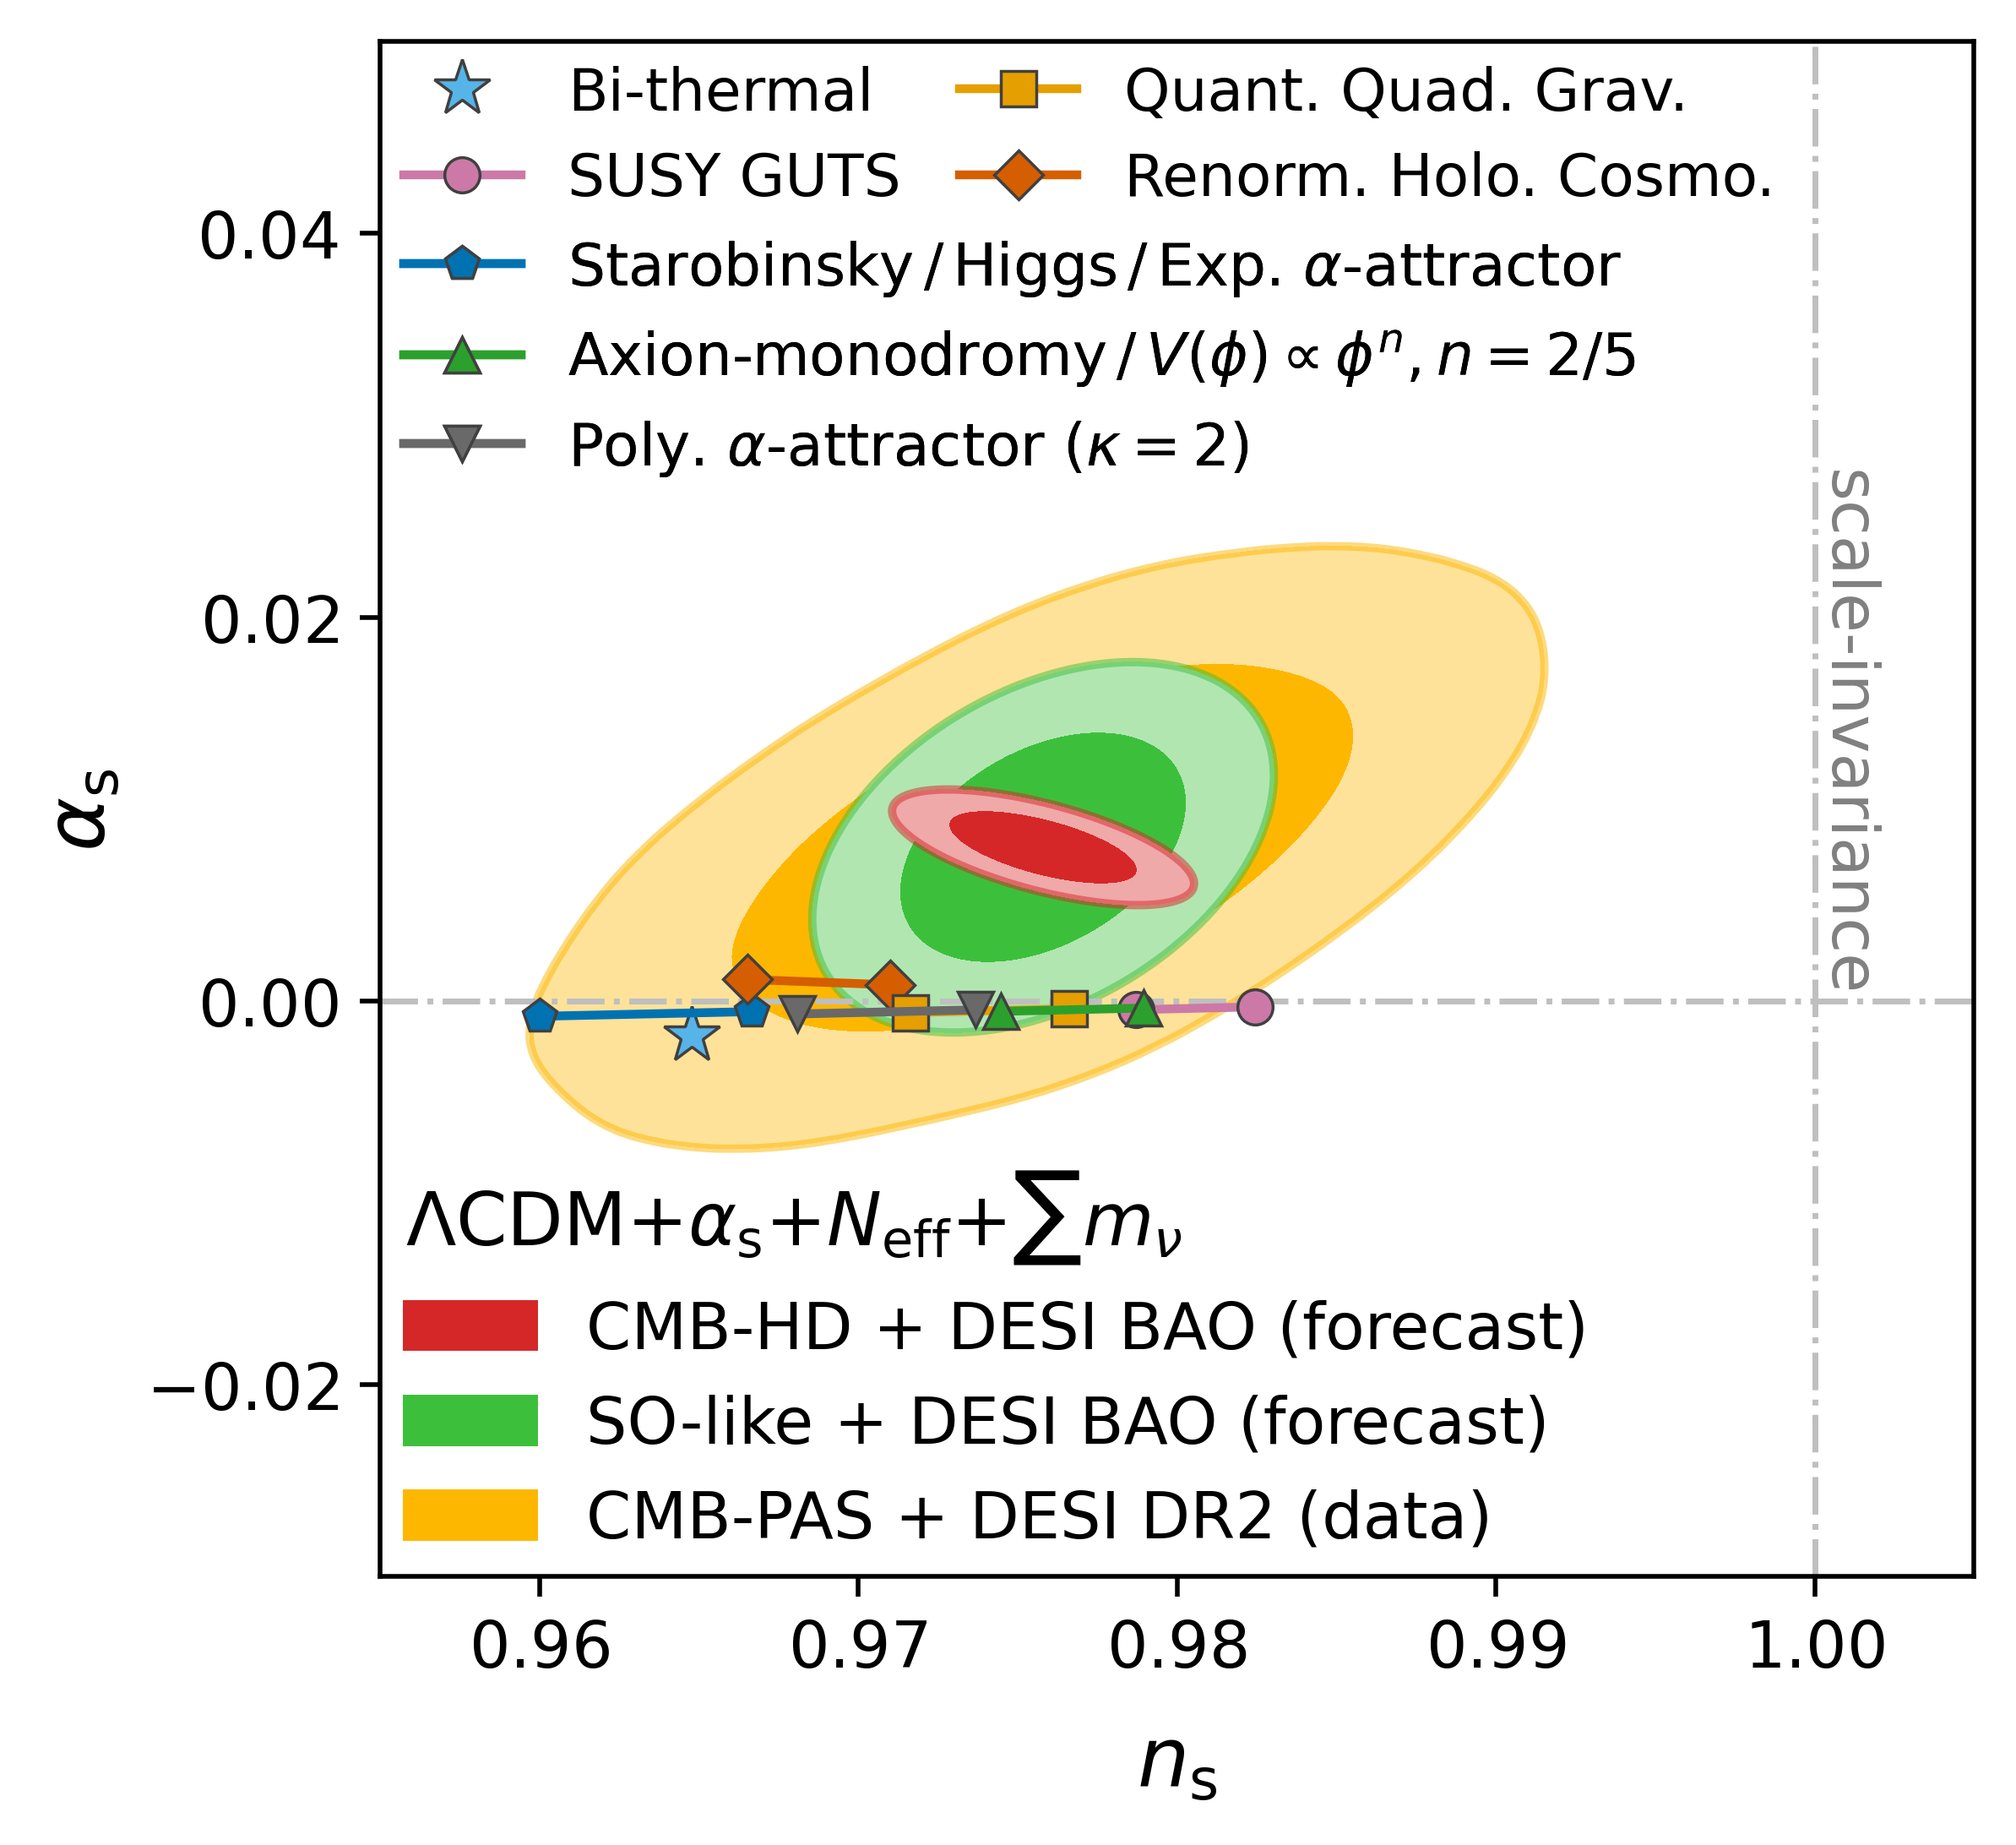

In [25]:
g_zoom = plots.get_subplot_plotter(subplot_size=5, subplot_size_ratio=0.9)

# plot the contours:
plt_samples = []
plt_colors = []
plt_lines = []
plt_lws = []
plt_filled = []
contour_args = []
for data_key in fig2_data_keys:
    for param_model in fig2_param_models:
        plt_samples.append(samples[data_key][param_model])
        plt_colors.append(fig2_colors[data_key][param_model])
        plt_lines.append(fig2_ls[param_model])
        plt_lws.append(fig2_lw[param_model])
        plt_filled.append(fig2_filled[param_model])
        contour_args.append({'alpha': fig2_alpha[param_model]})
g_zoom.plot_2d(plt_samples, ['ns', 'nrun'], filled=plt_filled,
               colors=plt_colors, ls=plt_lines, lws=plt_lws,
               contour_args=contour_args)

ax_zoom = g_zoom.subplots[0, 0]

# label the contours:
handles = [mpatches.Patch(color=exp_colors[data_key], label=exp_labels[data_key])
           for data_key in fig2_data_keys[::-1]]
legend = ax_zoom.legend(handles=handles, fontsize=11,
                        title=model_labels[fig2_param_models[0]],
                        title_fontsize=12.5, alignment='left',
                        loc='lower left', bbox_to_anchor=(0, 0), **flat_legend)
g_zoom.fig.add_artist(legend)

# lines for zero running (nrun = 0) and scale-invariance (ns = 1):
ax_zoom.axhline(**param_line_kwargs)
ax_zoom.axvline(x=1, **param_line_kwargs)
ax_zoom.text(1.000, 0.001, 'scale-invariance', fontsize=11, rotation=270,
             rotation_mode='default', color='0.5',
             verticalalignment='baseline', horizontalalignment='left')

# inflation models:
model_handles = {}
for imodel in plt_inflation_models:
    model_handle, = ax_zoom.plot(inflation_models[imodel]['ns'],
                                 inflation_models[imodel]['nrun'],
                                 markeredgecolor='0.25', markeredgewidth=0.5,
                                 **inflation_models[imodel]['kwargs'])
    model_handles[imodel] = model_handle

# two legend groups for the models, stacked top to bottom:
top_handles = [model_handles['bithermal'], model_handles['sbs'],
               model_handles['qqg'], model_handles['rhc']]      # 2 columns
mid_handles = [model_handles['starobinsky'], model_handles['mono'],
               model_handles['poly']]                           # 1 column

legend_top = ax_zoom.legend(handles=top_handles, fontsize=10, columnspacing=1,
                            bbox_to_anchor=(0, 1), loc='upper left', ncol=2,
                            **flat_legend)
ax_zoom.add_artist(legend_top)
legend_mid = legend_below(ax_zoom, legend_top, mid_handles, ncol=1, **flat_legend)

ax_zoom.set_xlim(0.955, 1.005)
ax_zoom.set_ylim(-0.030, 0.05)

save_figure('fig2')
plt.show()

## Distance of the inflation models from the forecast centers

Mahalanobis distance of each inflation model's
($n_\mathrm{s}$, $\alpha_\mathrm{s}$) prediction from the forecast center,
using the marginalized 2d covariance from the Fisher matrix. This gives the
effective "number of sigma" at which each model could be distinguished.

In [26]:
def mahalanobis_distances(fisher_result, means_dict, model_dict):
    """Mahalanobis distance in the (nrun, ns) plane for each model in
    `model_dict`, given a `(fisher_matrix, param_names)` pair. The parameter
    indices are looked up by name from `param_names`."""
    fisher_matrix, param_names = fisher_result
    covmat = np.linalg.inv(fisher_matrix)
    idx = [param_names.index('nrun'), param_names.index('ns')]
    covmat_cut = covmat[np.ix_(idx, idx)]
    means = np.array([means_dict['nrun'], means_dict['ns']])

    results = {}
    for model_name, model_data in model_dict.items():
        dists = []
        for ns, nrun in zip(np.asarray(model_data['ns']),
                            np.asarray(model_data['nrun'])):
            diff = np.array([nrun, ns]) - means   # order matches `means`
            dists.append(np.sqrt(diff @ np.linalg.solve(covmat_cut, diff)))
        results[model_name] = np.array(dists)
    return results


print('CMB-HD (CLASS) Fisher, 9-parameter model:')
for k, v in mahalanobis_distances(class_fisher_matrix_with_desi,
                                  mcmc_fid_params, inflation_models).items():
    print(f'  {k}: {v}')

print('\nCMB-HD (CAMB) Fisher, 12-parameter model with feedback:')
for k, v in mahalanobis_distances(camb_fisher_matrix_with_desi_feedback,
                                  mcmc_fid_params, inflation_models).items():
    print(f'  {k}: {v}')

CMB-HD (CLASS) Fisher, 9-parameter model:
  starobinsky: [17.746854   13.57443732]
  bithermal: [15.86748543]
  rhc: [12.03757242  9.79143258]
  qqg: [10.92607307  8.4496917 ]
  sbs: [7.75225289 6.82980161]
  mono: [9.49323308 7.59965254]
  poly: [12.89759018  9.77072154]

CMB-HD (CAMB) Fisher, 12-parameter model with feedback:
  starobinsky: [13.61983163  9.84396438]
  bithermal: [11.56738034]
  rhc: [8.94599665 6.82562432]
  qqg: [7.47098857 5.58827044]
  sbs: [5.24680881 5.28066765]
  mono: [6.31209553 5.17075594]
  poly: [9.19329486 6.53903161]


# Figure 3

Current and forecasted constraints on $e^{-2\tau} \mathcal{P}(k)$ for a
binned primordial power spectrum. The current constraints (P-ACT-LB and
CMB-PAS) come from MCMC chains with 7 $k$ bins; the SO-like and CMB-HD
forecasts come from binned-$\mathcal{P}(k)$ Fisher matrices with 7 and 11
bins, respectively.

In [27]:
# SO only measures the first 7 of the 11 CMB-HD k bins.
so_max_bin = 7

# varied parameters for the binned-P(k) Fisher matrices:
params_binned_pk = [f'Pk{i+1}' for i in range(11)] + ['H0', 'tau', 'ombh2', 'omch2']
params_binned_pk_so = [f'Pk{i+1}' for i in range(so_max_bin)] + ['H0', 'tau', 'ombh2', 'omch2']

# k bin edges [Mpc^-1] for the 11-bin (+ 1 lower-edge) binning:
pk_bin_edges = [5.623413251903490700e-05, 3.667637511098258835e-03,
                8.505899211272888866e-03, 1.972668268698882926e-02,
                4.574966151931515734e-02, 1.061015459285717805e-01,
                2.460682259622835044e-01, 5.706756795889451617e-01,
                1.323497700691443235e+00, 3.069424940269466440e+00,
                7.118538595893407539e+00, 1.650914836730800417e+01,
                3.828763111167506139e+01]

In [28]:
def hd_Pk(k):
    """Fiducial power-law primordial spectrum P_R(k), with k in Mpc^-1."""
    k_0 = 0.05
    A_s = np.exp(3.044) / 1e10
    n_s = 0.9649
    return A_s * (k / k_0)**(n_s - 1)


# k bin centers and edges for the 11-bin CMB-HD binning:
binning = utils.load_from_file(
    os.path.join(binning_data_path, 'hd_pk_wavenumbers_11bins.txt'),
    ['k bin center [Mpc^-1]', 'lower bin edge [Mpc^-1]', 'upper bin edge [Mpc^-1]'])

# fiducial P(k) and 10^9 e^{-2 tau} P(k) at the bin centers:
hd_pk_eleven_bins = [hd_Pk(k) for k in binning['k bin center [Mpc^-1]']]
eneg2tau_hd_pk_eleven_bins = [1e9 * np.exp(-2 * tau) * pk for pk in hd_pk_eleven_bins]

In [29]:
# Binned-P(k) Fisher matrices for CMB-HD (11 bins) and SO-like (7 bins),
# produced with `hdinitpk`. These have the tau prior applied and no DESI,
# matching the paper.
fisher_matrix_binned_pk = load_saved_fisher('hd_binned_pk_lensed_11bins')
fisher_matrix_binned_pk_so = load_saved_fisher('so_binned_pk_lensed_7bins')


In [30]:
def get_eneg2tau_pk_errors(fisher_matrix, fisher_params, fid_params,
                           n_samples=100000, random_state=None):
    """
    Marginalized error on e^{-2 tau} * Pk_n for each Pk bin, computed by
    sampling rather than by analytic (delta-method) error propagation.

    Steps (following getdist):
      1. Represent the Fisher forecast as a multivariate Gaussian via
         GaussianND, centered on the fiducial values, with the inverse
         Fisher matrix as the parameter covariance. This carries the full
         tau <-> bin correlations.
      2. Draw samples from that distribution.
      3. For each bin, build the derived quantity e^{-2 tau} Pk_n from the
         sampled tau and Pk_n values and append it with addDerived.
      4. Read off the marginalized error bar from the resulting distribution.
    """
    params = list(fisher_params)  # list of param name strings

    # Mean vector in the same order as fisher_params.
    mean = np.array([fid_params[p] for p in params])

    # Parameter covariance = inverse Fisher matrix.
    cov = np.linalg.inv(fisher_matrix)

    # Multivariate Gaussian centered on the fiducial point.
    gauss = GaussianND(mean, cov, names=params)

    # Independent samples carrying the full correlation structure.
    gauss_samples = gauss.MCSamples(size=n_samples, names=params,
                                    random_state=random_state)

    p = gauss_samples.getParams()
    tau_samp = getattr(p, 'tau')

    errors = {}
    for n in range(0, 62):
        pk_name = f'Pk{n}'
        if pk_name not in params:
            continue

        pk_samp = getattr(p, pk_name)

        # Derived quantity for this bin, sample by sample.
        derived = np.exp(-2.0 * tau_samp) * pk_samp
        gauss_samples.addDerived(derived, name=f'eneg2tau_{pk_name}')

        # Marginalized error bar from the derived distribution.
        errors[pk_name] = np.std(derived, ddof=1)

    return errors


# Fiducial values for the binned-P(k) Fisher parameters (including the
# baryonic feedback + kSZ parameters, used for the Figure 5 Fisher matrices).
binned_pk_fids = {'ombh2': 0.02237, 'omch2': 0.1200, 'tau': 0.0544,
                  'H0': 67.36, 'HMCode_logT_AGN': 7.8, 'A_ksz': 1.0,
                  'n_ksz': 0.0}
for n, pk_val in enumerate(hd_pk_eleven_bins, start=1):
    binned_pk_fids[f'Pk{n}'] = pk_val

eneg2tau_pk_errors = get_eneg2tau_pk_errors(
    fisher_matrix_binned_pk[0], fisher_matrix_binned_pk[1], binned_pk_fids)
eneg2tau_pk_errors_so = get_eneg2tau_pk_errors(
    fisher_matrix_binned_pk_so[0], fisher_matrix_binned_pk_so[1], binned_pk_fids)

# forecasted 1-sigma errors on 10^9 e^{-2 tau} P(k) per bin:
hd_err = [1e9 * eneg2tau_pk_errors[f'Pk{i+1}'] for i in range(11)]
so_err = [1e9 * eneg2tau_pk_errors_so[f'Pk{i+1}'] for i in range(so_max_bin)]

Removed no burn in
Removed no burn in


In [31]:
# Styling shared by the binned-P(k) figures (Figures 3, 5, 10, and 11):
axis_label_fontsize = 12
legend_fontsize = 11
elinewidth = 1
pk_ylabel_top = r"$10^9 \, e^{-2\tau} \, \mathcal{P}(k)$"
pk_ylabel_frac = r"$\frac{\sigma\left[e^{-2\tau} \, \mathcal{P}(k)\right]}{e^{-2\tau} \, \mathcal{P}(k)}$"
pk_xlabel = r"Wavenumber, $k$ [Mpc$^{-1}$]"

# k values of the 7 chain bins (arithmetic bin centers):
ks_chains_7bin = [0.0018619358218086469, 0.006086768361185574,
                  0.014116290949130859, 0.032738172103151996,
                  0.07592560372394347, 0.17608488594542765,
                  0.40837195277561433]

In [32]:
# Super-renormalizable holographic cosmology, best-fit SRHC constraints from
# CMB-PAS (this work):
#   10^9 * e^{-2 tau} * As = 1.804 +/- 0.008
#   10^3 * g               = -10.7 +/- 1.6
#   beta                   = 2.7   +/- 0.3
k0_pivot = 0.05                # pivot scale [Mpc^-1]
eneg2tau_As_srhc = 1.804       # 10^9 * e^{-2 tau} * As
g_srhc = -10.7e-3              # 10^3 * g = -10.7
beta_srhc = 2.7


def srhc_Pk_eneg2tau(k, As109=eneg2tau_As_srhc, g=g_srhc, beta=beta_srhc):
    """Returns 10^9 * e^{-2 tau} * P(k) for the SRHC model; the e^{-2 tau}
    factor is folded into the quoted amplitude (As enters only as an overall
    numerator)."""
    return As109 / (1.0 + (g * k0_pivot / k) * np.log(np.abs(k / (beta * g * k0_pivot))))

P-ACT-LB fractional errors: [0.05650929137586211, 0.01774859957777609, 0.009253887585524414, 0.006115143543793314, 0.004742634351662631, 0.006816239905074132, 0.11384602670207733]
CMB-PAS fractional errors: [0.05512784010722044, 0.016557820052317238, 0.00802997578481762, 0.005540646656764346, 0.0031609114089125195, 0.005192907524959543, 0.09162473256290447]
CMB-HD fractional errors: [0.020503610436069488, 0.00870313606268866, 0.004213925420221956, 0.0014069764762033516, 0.0007972627379708217, 0.0019715310210717345, 0.008189712117416849, 0.01272958821705001, 0.08601994730450106, 0.5897860553638249, 4.284736914366591]
SO-like fractional errors: [0.022801068473709198, 0.007049272388089041, 0.004380312448659168, 0.001472268304588529, 0.001011121295961467, 0.011284376692245562, 0.09069353683422664]
saved /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/fig3-august-26-2026.png


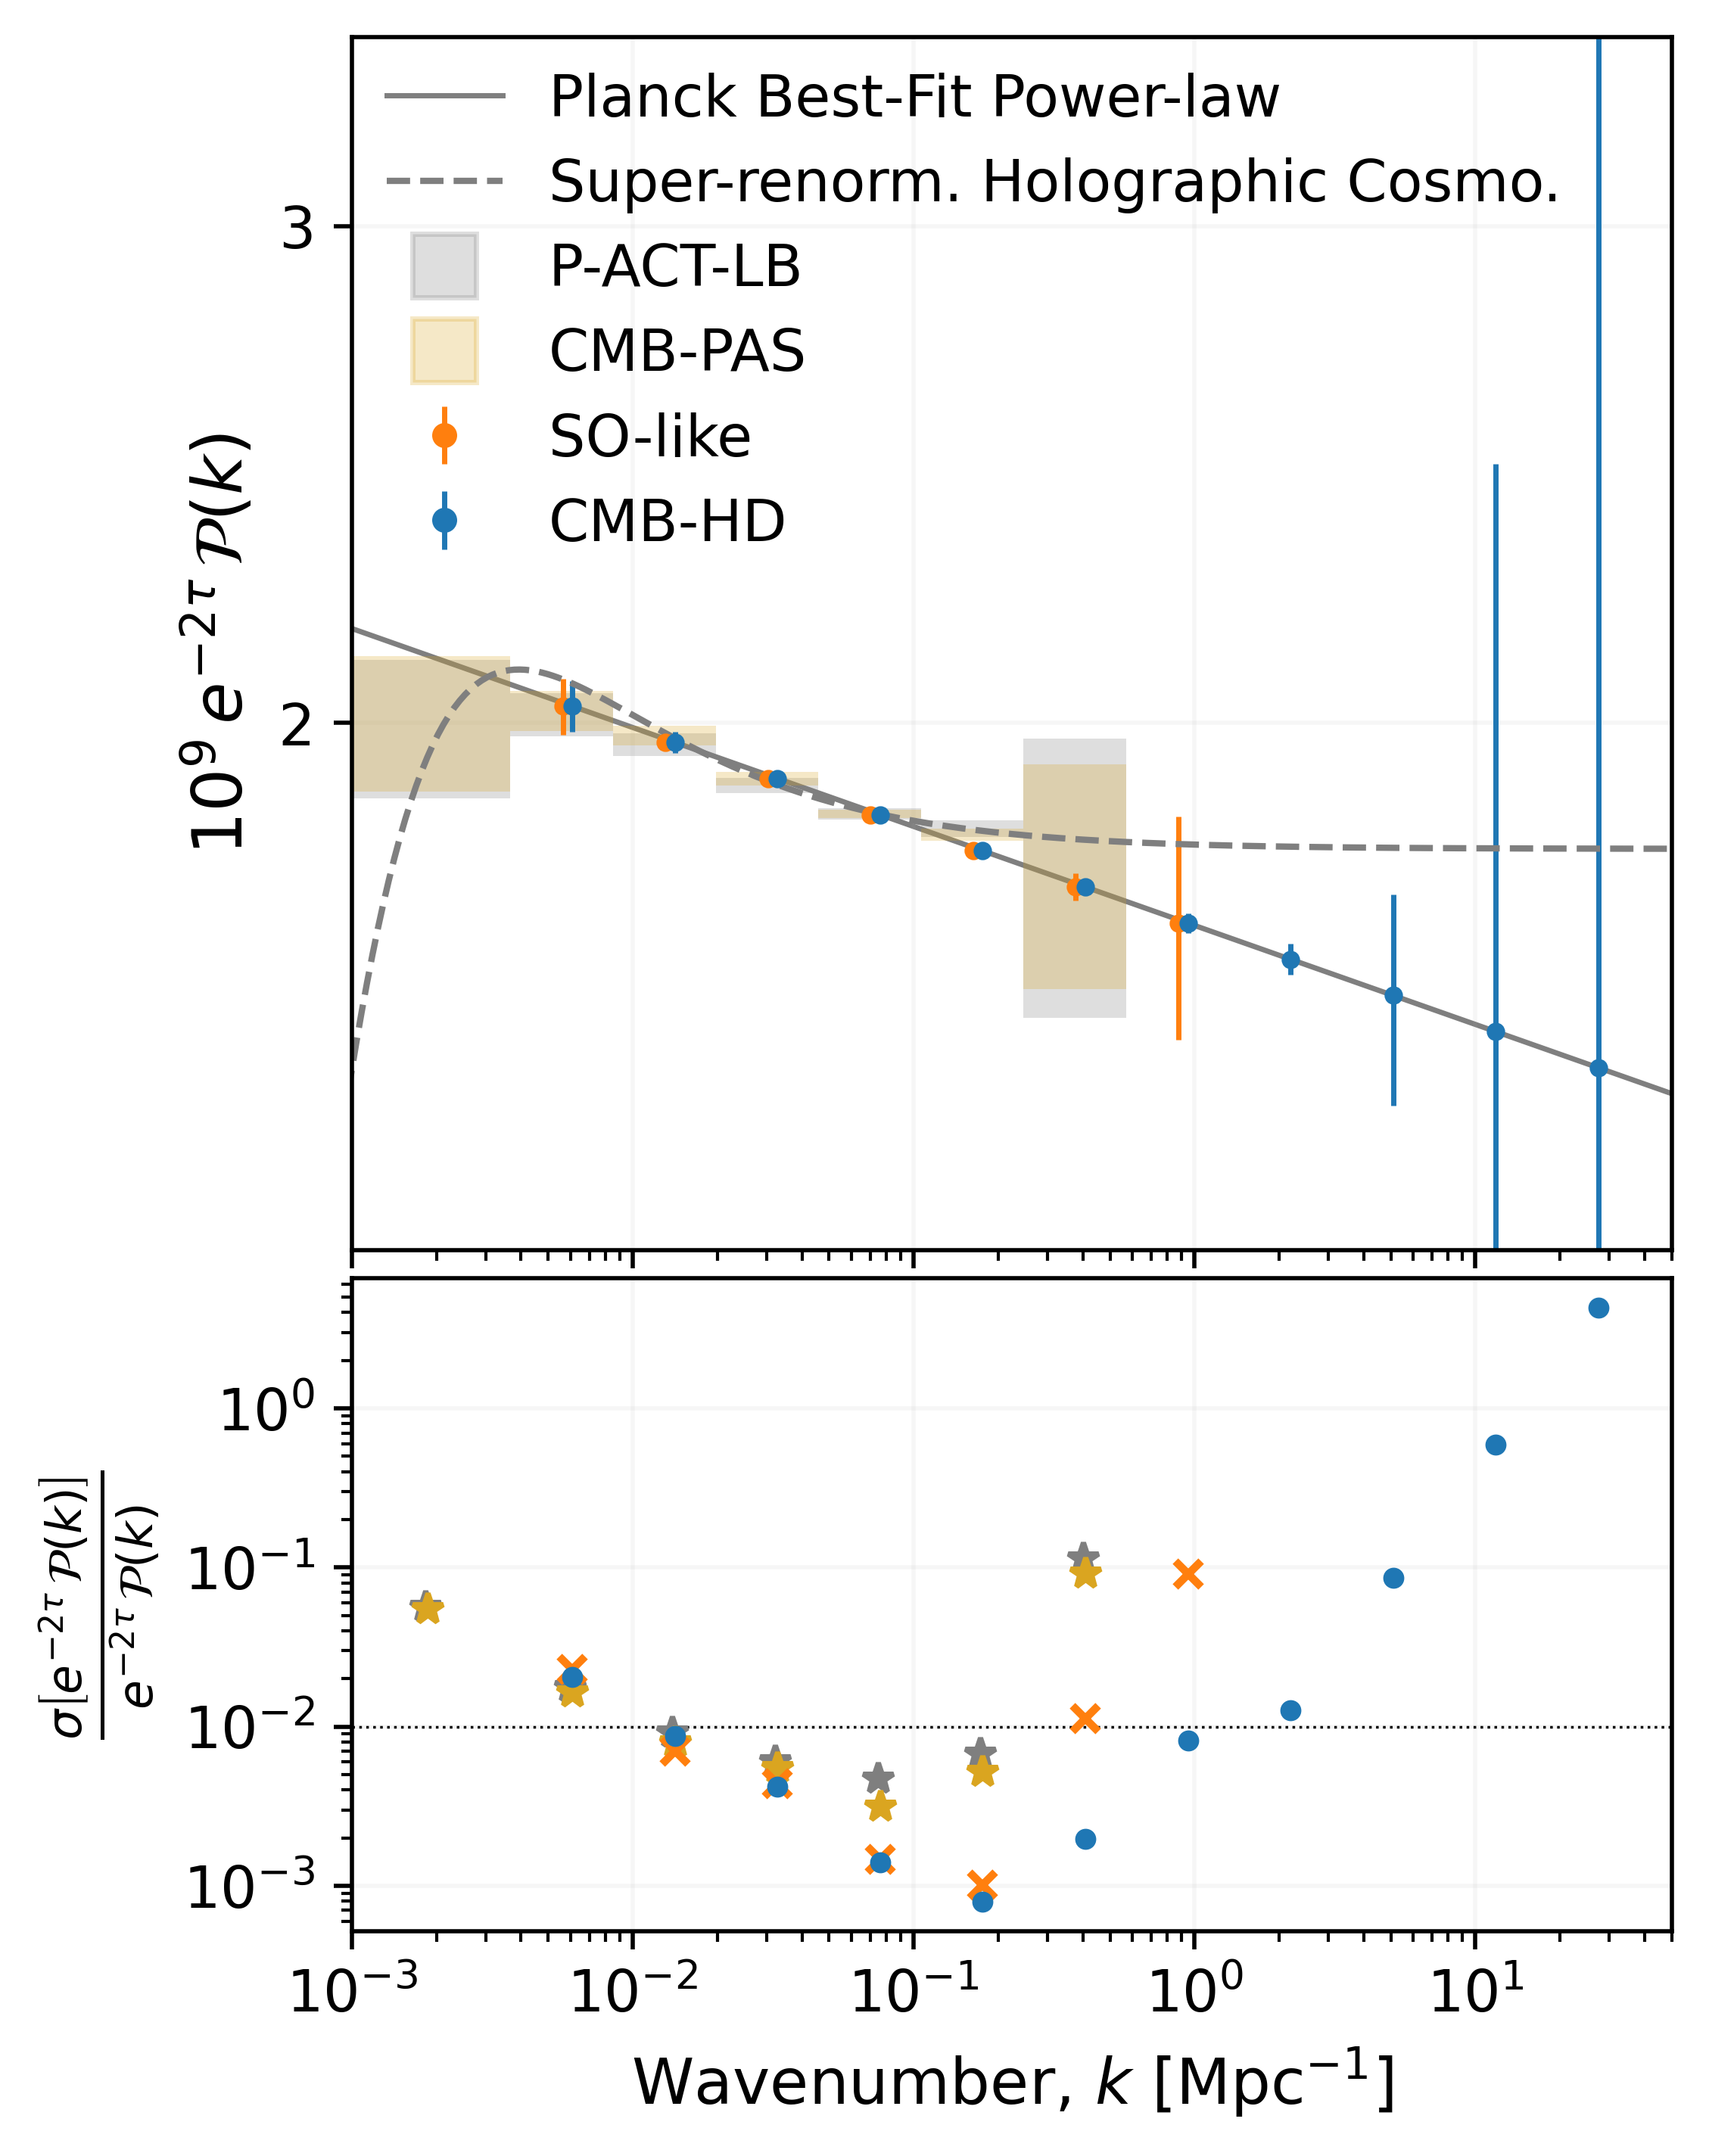

In [33]:
fig3_legend_kwargs = {
    'frameon': False,
    'fontsize': legend_fontsize,
    'loc': 'upper left',
    'bbox_to_anchor': (0, 1),
    'markerscale': 1.5,
    'borderpad': 0.1,
}

plt_kmin, plt_kmax = 1e-3, 50

ks_extended = np.logspace(np.log10(1e-8), np.log10(50), 500)
hd_pk_extended = [1e9 * np.exp(-2 * tau) * hd_Pk(k) for k in ks_extended]
srhc_pk_extended = [srhc_Pk_eneg2tau(k) for k in ks_extended]

fig, (ax_main, ax_frac) = plt.subplots(
    2, 1, figsize=(4.5, 6.5), dpi=500, facecolor='w', sharex=True,
    gridspec_kw={'height_ratios': [0.65, 0.35], 'hspace': 0.03})

fig3_sample_sets = [
    ('P-ACT-LB', p_act_means, p_act_asymmetric_errors, 'tab:grey'),
    ('CMB-PAS', pas_means, pas_asymmetric_errors, 'goldenrod'),
]

# --- main panel ---
set_loglog(ax_main)
ax_main.plot(ks_extended, hd_pk_extended, linestyle='-', color='tab:gray',
             linewidth=1, zorder=1, label='Planck Best-Fit Power-law')
for label, means, (lower_errs, upper_errs), color in fig3_sample_sets:
    add_box_errors(ax_main, ks_chains_7bin, means, lower_errs, upper_errs,
                   color=color, alpha=0.25, edges=pk_bin_edges[:8])
ax_main.errorbar(binning['k bin center [Mpc^-1]'][0:so_max_bin] * (1 - 0.075),
                 eneg2tau_hd_pk_eleven_bins[0:so_max_bin], yerr=so_err,
                 fmt='.', markersize=5, capsize=0.0, elinewidth=elinewidth,
                 color='tab:orange', label='SO-like')
ax_main.errorbar(binning['k bin center [Mpc^-1]'], eneg2tau_hd_pk_eleven_bins,
                 yerr=hd_err, fmt='.', markersize=5, capsize=0.0,
                 elinewidth=elinewidth, color='tab:blue', label='CMB-HD')
ax_main.plot(ks_extended, srhc_pk_extended, linestyle='--', color='tab:grey',
             linewidth=1.2, zorder=2, label='Super-renorm. Holographic Cosmo.')
ax_main.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
ax_main.set_yticks(list(range(1, 7)))
ax_main.set_yticklabels([str(i) for i in range(1, 7)])
ax_main.set_ylabel(pk_ylabel_top, fontsize=axis_label_fontsize + 1)
for label, means, errs, color in fig3_sample_sets:
    ax_main.plot([], [], 's', color=color, alpha=0.25, markersize=8, label=label)
ax_main.legend(**fig3_legend_kwargs)
ax_main.set_ylim(1.3, 3.5)
ax_main.set_xlim(plt_kmin, plt_kmax)
ax_main.grid(alpha=0.1)

# --- fractional-error panel ---
set_loglog(ax_frac)
ax_frac.axhline(y=0.01, color='k', ls=':', lw=0.5)
offset_ks = []
for i in range (0, len(ks_chains_7bin)):
    offset_ks.append(0.98 * ks_chains_7bin[i])
ks = [offset_ks, ks_chains_7bin,]
i=0
for label, means, (lower_errs, upper_errs), color in fig3_sample_sets:
    residuals = [np.mean([lower_errs[i], upper_errs[i]]) / means[i]
                 for i in range(len(means))]
    print(f'{label} fractional errors:', residuals)
    ax_frac.plot(ks[i], residuals, marker='*', markersize=6,
                 ls='None', color=color)
    i+=1
residual_hd = [hd_err[i] / eneg2tau_hd_pk_eleven_bins[i] for i in range(len(hd_err))]
residual_so = [so_err[i] / eneg2tau_hd_pk_eleven_bins[i] for i in range(len(so_err))]
print('CMB-HD fractional errors:', residual_hd)
print('SO-like fractional errors:', residual_so)
ax_frac.plot(binning['k bin center [Mpc^-1]'][0:so_max_bin], residual_so,
             marker='x', markersize=5, ls='None', color='tab:orange', markeredgewidth = 1.5)
ax_frac.plot(binning['k bin center [Mpc^-1]'], residual_hd,
             marker='.', markersize=6, ls='None', color='tab:blue')
ax_frac.set_xlabel(pk_xlabel, fontsize=axis_label_fontsize)
ax_frac.set_ylabel(pk_ylabel_frac, fontsize=axis_label_fontsize + 1)
ax_frac.margins(0.05)
ax_frac.set_xlim(plt_kmin, plt_kmax)
ax_frac.grid(alpha=0.1)

plt.subplots_adjust(hspace=0.03)
save_figure('fig3', bbox_inches='tight')
plt.show()

# Figure 4

Triangle plot of the full 9-parameter posterior: CMB-PAS + DESI DR2 (MCMC)
versus the SO-like and CMB-HD Fisher forecasts.

saved /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/fig4-august-26-2026.png


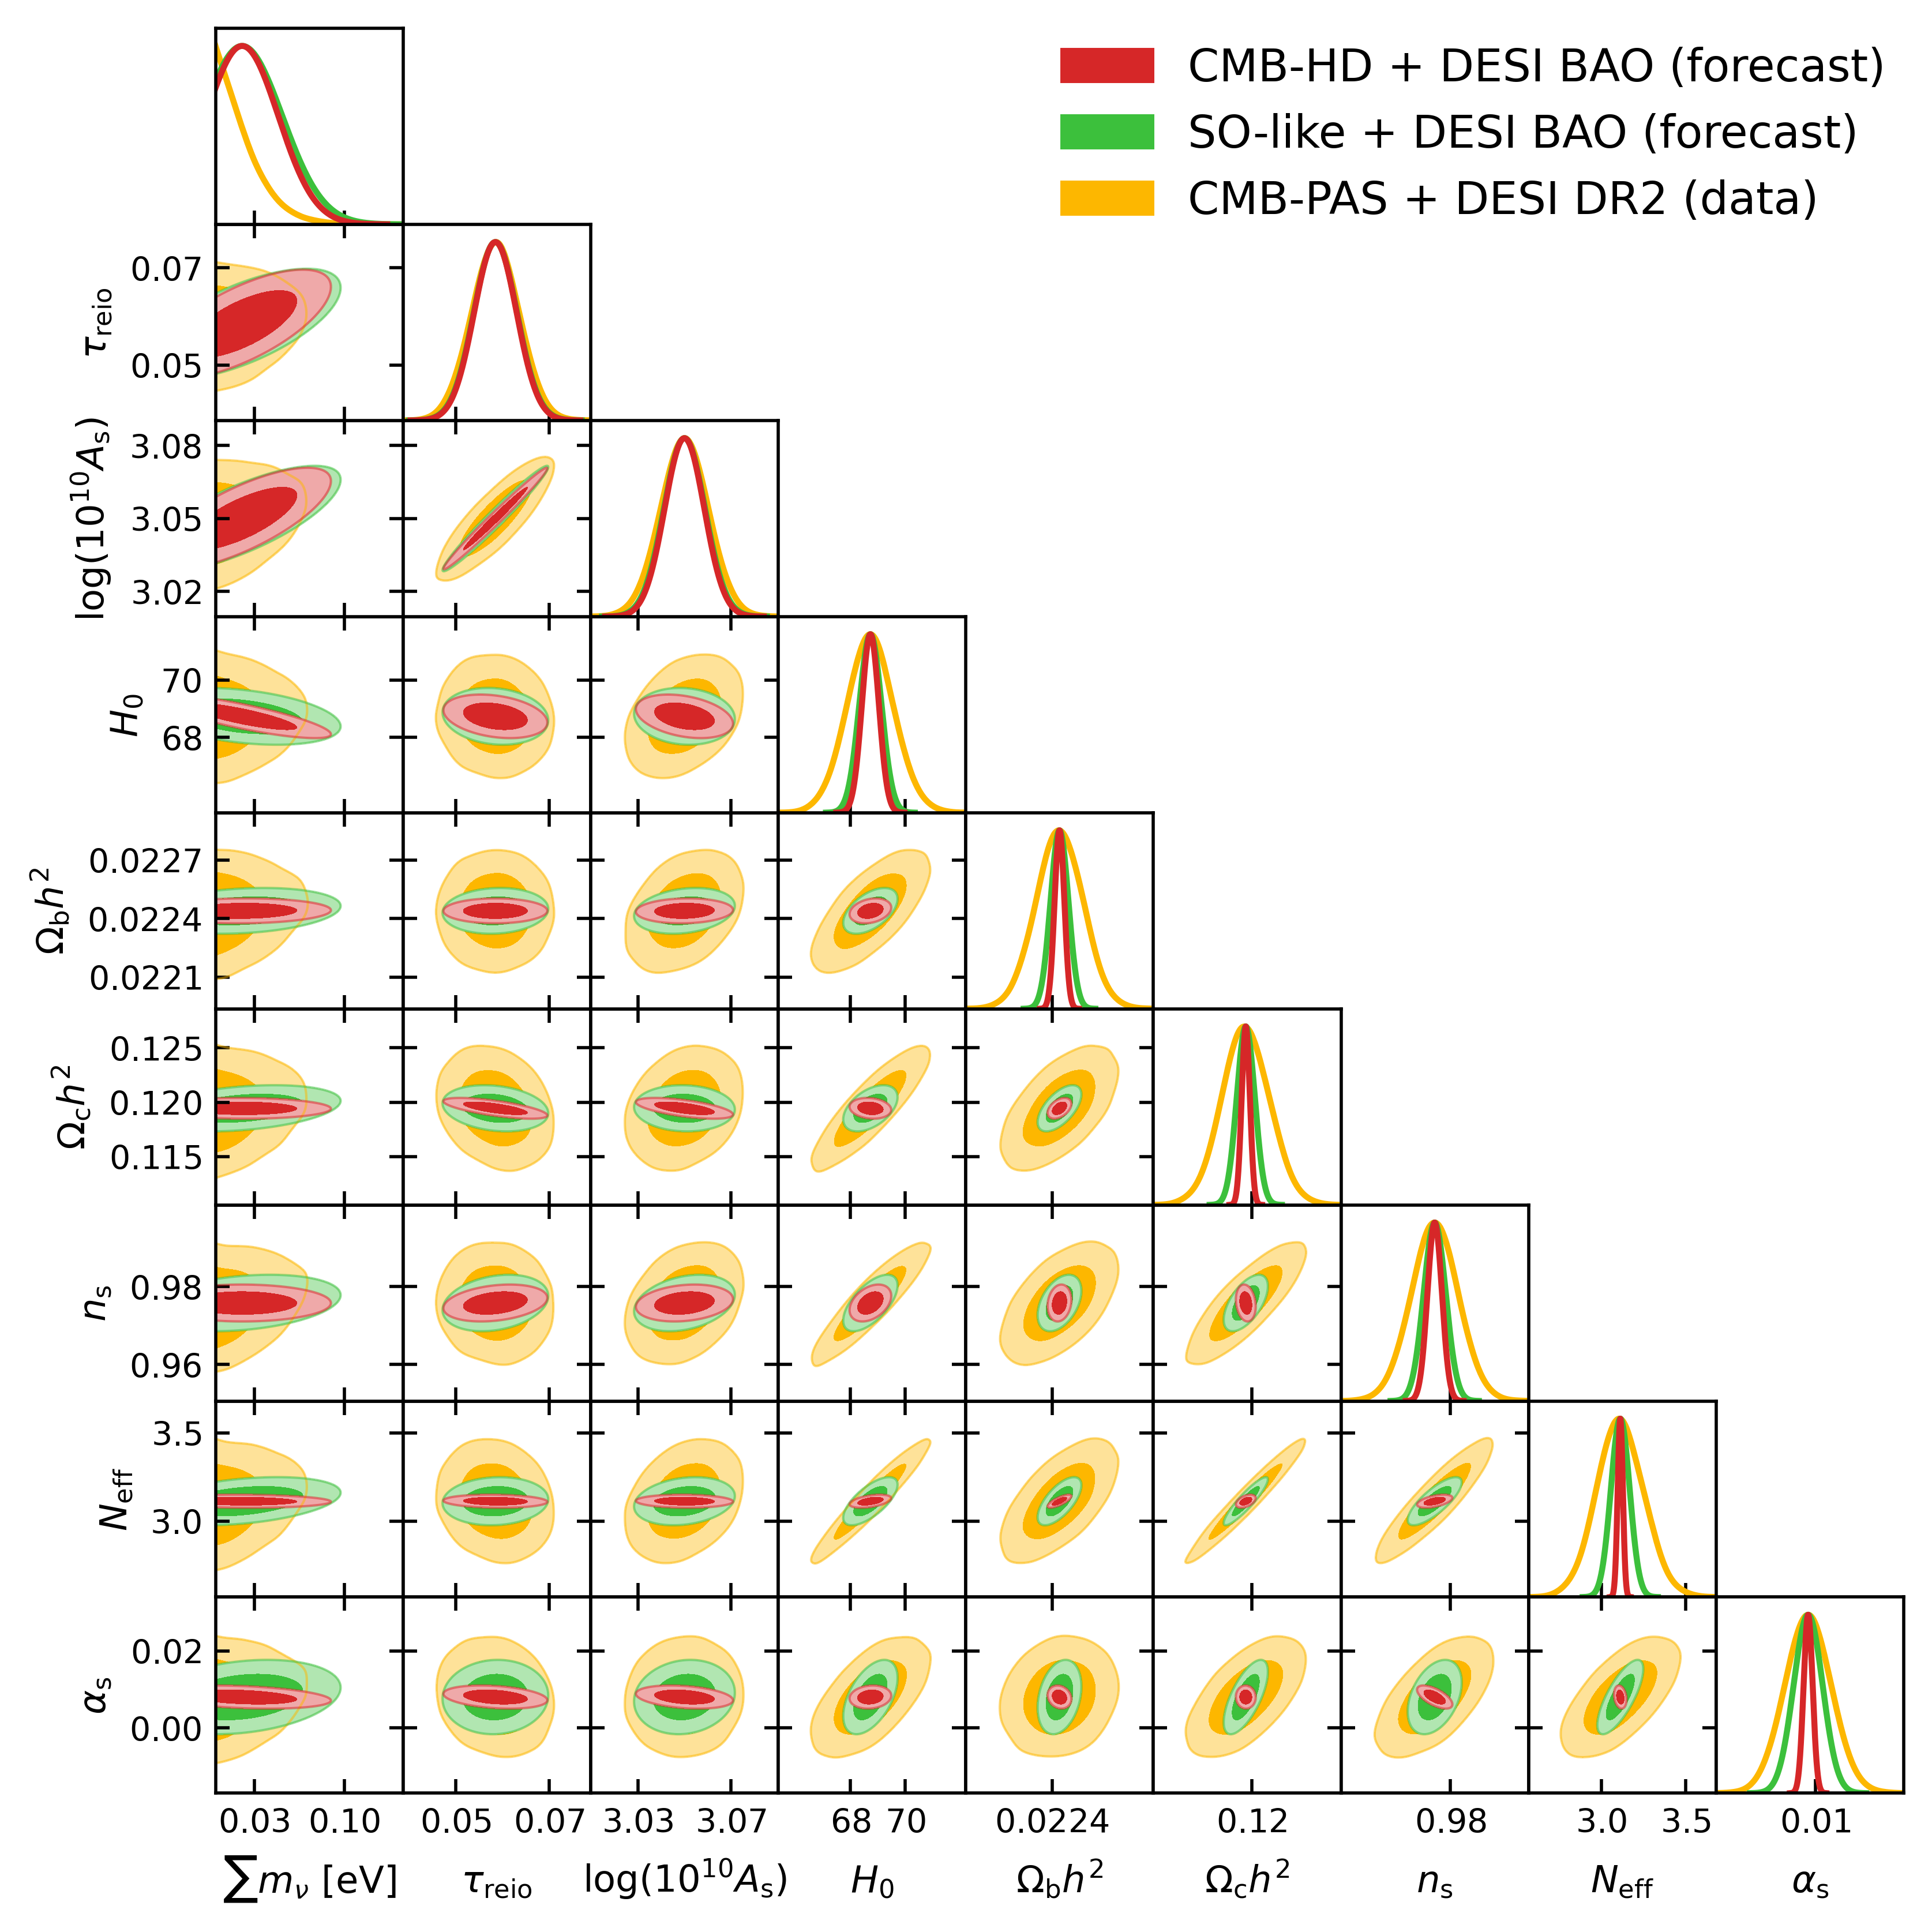

In [34]:
triangle_plot_params = ['mnu', 'tau', 'logA', 'H0', 'ombh2', 'omch2',
                        'ns', 'nnu', 'nrun']
triangle_param_model = 'lcdm_nrun_nnu_mnu'
triangle_data_sets = ['spa', 'so', 'hd']

triangle_samples = [samples[data_set][triangle_param_model]
                    for data_set in triangle_data_sets]
triangle_labels = [exp_labels[data_set] for data_set in triangle_data_sets]
triangle_colors = [exp_colors[data_set] for data_set in triangle_data_sets]
lw_1d = [1.5, 1.5, 1.5]
alphas = [0.6, 0.6, 1.0]

g = plots.get_subplot_plotter(width_inch=6.5)
g.settings.scaling_factor = 1
g.settings.legend_fontsize = 14
g.settings.axes_fontsize = 11
g.settings.axes_labelsize = 12
g.settings.constrained_layout = True
g.settings.figure_legend_frame = False
g.triangle_plot(triangle_samples,
                params=triangle_plot_params,
                filled=True,
                diag1d_kwargs={'lws': lw_1d},
                contour_colors=triangle_colors,
                contour_args=[{'alpha': 1.0}, {'alpha': 1.0}, {'alpha': 1.0}],
                legend_loc='upper right',
                legend_frame=True,
                legend_labels=triangle_labels,
                label_order=-1)

# reduce the tick clutter in the ombh2 column:
col = triangle_plot_params.index('ombh2')
for row in range(len(triangle_plot_params)):
    ax = g.subplots[row, col]
    if ax is not None:
        ax.set_xticks([0.0224])

save_figure('fig4')
plt.show()

# Figure 5

CMB-HD forecasted errors on the binned $e^{-2\tau} \mathcal{P}(k)$ when the
baryonic feedback and kSZ parameters are additionally varied, and when the
lensing reconstruction uses polarization-only estimators.

In [35]:
# The binned-P(k) + feedback + kSZ Fisher matrix, and the variant computed
# with the polarization-only lensing-noise covariance matrix (both produced
# with `hdinitpk`; tau and HMCode_logT_AGN priors and DESI already
# applied):
fisher_matrix_feedback = load_saved_fisher('hd_binned_pk_feedback_lensed')
fisher_matrix_feedback_pol = load_saved_fisher('hd_binned_pk_feedback_pol_lensed')

eneg2tau_pk_errors_feedback = get_eneg2tau_pk_errors(
    fisher_matrix_feedback[0], fisher_matrix_feedback[1], binned_pk_fids)

errs_feedback_pol = fisher.get_fisher_errors(*fisher_matrix_feedback_pol)
print(errs_feedback_pol)

eneg2tau_pk_errors_feedback_pol = get_eneg2tau_pk_errors(
    fisher_matrix_feedback_pol[0], fisher_matrix_feedback_pol[1], binned_pk_fids)

# forecasted 1-sigma errors on 10^9 e^{-2 tau} P(k) per bin:
feedback_err = [1e9 * eneg2tau_pk_errors_feedback[f'Pk{i+1}'] for i in range(11)]
feedback_pol_err = [1e9 * eneg2tau_pk_errors_feedback_pol[f'Pk{i+1}'] for i in range(11)]


Removed no burn in
{'A_ksz': 0.004876066790460706, 'H0': 0.12719567164241566, 'HMCode_logT_AGN': 0.0046788707392238825, 'Pk1': 4.875679506505137e-11, 'Pk10': 4.37470664875332e-09, 'Pk11': 2.6489182442269345e-08, 'Pk2': 2.2663433624028224e-11, 'Pk3': 1.2389229602534905e-11, 'Pk4': 1.3176104864581038e-11, 'Pk5': 1.3837704400954562e-11, 'Pk6': 1.4320520051005378e-11, 'Pk7': 2.985846578158269e-11, 'Pk8': 4.5388256858735575e-11, 'Pk9': 3.446871765232029e-10, 'n_ksz': 0.0066322027656367175, 'ombh2': 1.9508409326353455e-05, 'omch2': 0.0003404186462908786, 'tau': 0.003466138582895241}
Removed no burn in


saved /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/fig5-august-26-2026.png


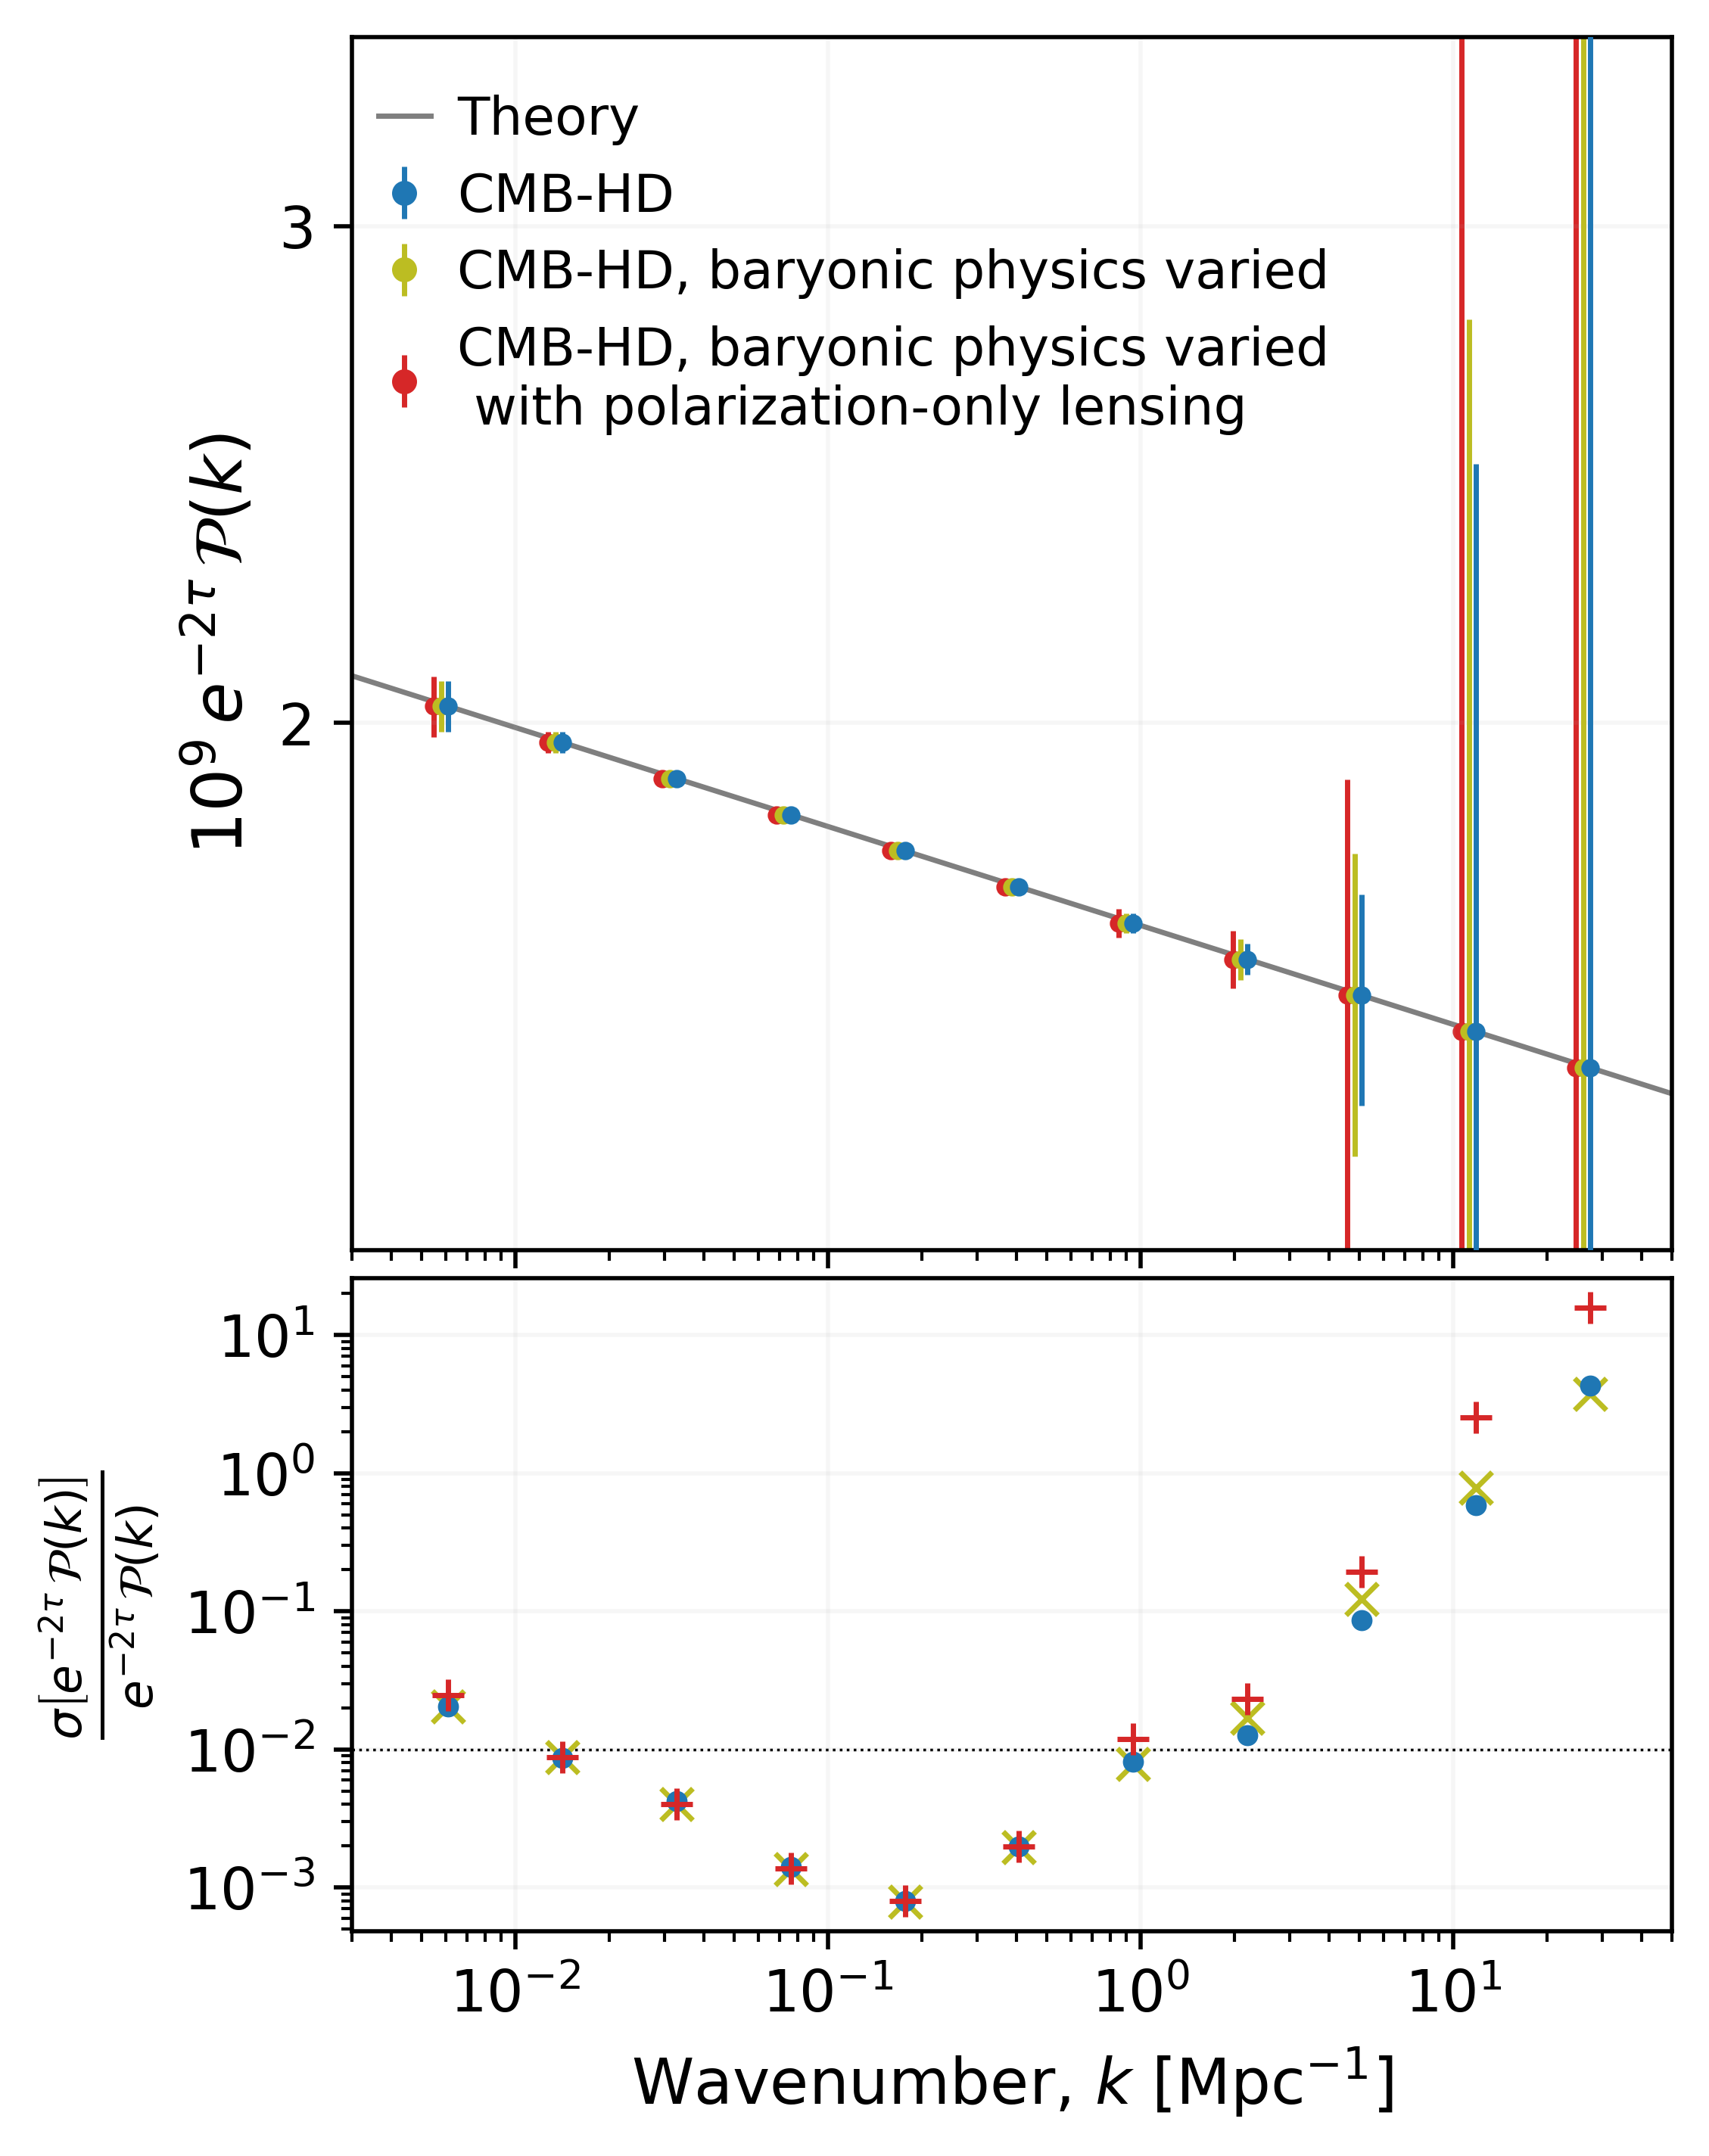

In [36]:
fig5_legend_kwargs = {
    'frameon': False,
    'fontsize': legend_fontsize - 1,
    'loc': 'upper left',
    'bbox_to_anchor': (0, 0.975),
    'markerscale': 1.5,
    'borderpad': 0,
    'handletextpad': 0.5,
    'handlelength': 1.0,
}

plt_kmin, plt_kmax = 3e-3, 50

fig, (ax_main, ax_frac) = plt.subplots(
    2, 1, figsize=(4.5, 6.5), dpi=500, facecolor='w', sharex=True,
    gridspec_kw={'height_ratios': [0.65, 0.35], 'hspace': 0.03})

yellowish = '#bdc736'

# --- main panel ---
set_loglog(ax_main)
ax_main.plot(ks_extended, hd_pk_extended, linestyle='-', color='tab:gray',
             linewidth=1, zorder=1, label='Theory')
# CMB-HD (all k bins) at the bin centers:
ax_main.errorbar(binning['k bin center [Mpc^-1]'], eneg2tau_hd_pk_eleven_bins,
                 yerr=hd_err, fmt='.', markersize=5, capsize=0.0,
                 elinewidth=elinewidth, color='tab:blue', zorder=3,
                 label='CMB-HD')
# feedback series, offset left so the points don't overlap:
ax_main.errorbar(binning['k bin center [Mpc^-1]'] * (1 - 0.05),
                 eneg2tau_hd_pk_eleven_bins, yerr=feedback_err,
                 fmt='.', markersize=5, capsize=0.0, elinewidth=elinewidth,
                 color='tab:olive', zorder=2,
                 label='CMB-HD, baryonic physics varied')
# feedback with the polarization-only lensing covmat, furthest left:
ax_main.errorbar(binning['k bin center [Mpc^-1]'] * (1 - 0.1),
                 eneg2tau_hd_pk_eleven_bins, yerr=feedback_pol_err,
                 fmt='.', markersize=5, capsize=0.0, elinewidth=elinewidth,
                 color='tab:red', zorder=1,
                 label='CMB-HD, baryonic physics varied\n with polarization-only lensing')
ax_main.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
ax_main.set_yticks(list(range(1, 7)))
ax_main.set_yticklabels([str(i) for i in range(1, 7)])
ax_main.set_ylabel(pk_ylabel_top, fontsize=axis_label_fontsize + 1)
ax_main.legend(**fig5_legend_kwargs)
ax_main.set_ylim(1.3, 3.5)
ax_main.set_xlim(plt_kmin, plt_kmax)
ax_main.grid(alpha=0.1)

# --- fractional-error panel ---
set_loglog(ax_frac)
ax_frac.axhline(y=0.01, color='k', ls=':', lw=0.5)
residual_feedback = [feedback_err[i] / eneg2tau_hd_pk_eleven_bins[i]
                     for i in range(len(feedback_err))]
residual_feedback_pol = [feedback_pol_err[i] / eneg2tau_hd_pk_eleven_bins[i]
                         for i in range(len(feedback_pol_err))]
ax_frac.plot(binning['k bin center [Mpc^-1]'], residual_feedback,
             marker='x', markersize=6, ls='None', color='tab:olive')
ax_frac.plot(binning['k bin center [Mpc^-1]'], residual_hd,
             marker='.', markersize=6, ls='None', color='tab:blue')
ax_frac.plot(binning['k bin center [Mpc^-1]'], residual_feedback_pol,
             marker='+', markersize=6, ls='None', color='tab:red')
ax_frac.set_xlabel(pk_xlabel, fontsize=axis_label_fontsize)
ax_frac.set_ylabel(pk_ylabel_frac, fontsize= axis_label_fontsize + 1)
ax_frac.margins(0.05)
ax_frac.set_xlim(plt_kmin, plt_kmax)
ax_frac.grid(alpha=0.1)

plt.subplots_adjust(hspace=0.03)
save_figure('fig5', bbox_inches='tight')
plt.show()

In [37]:
# Fractional change in the errors when varying the baryonic physics
# parameters (and additionally switching to polarization-only lensing).
print('1 - sigma(feedback) / sigma(fiducial) per bin:')
for i in range(11):
    print(f'  {1 - feedback_err[i] / hd_err[i]}')
print('\n1 - sigma(feedback, pol-only lensing) / sigma(fiducial) per bin:')
for i in range(11):
    print(f'  {1 - feedback_pol_err[i] / hd_err[i]}')
print('\nk bin centers [Mpc^-1]:', binning['k bin center [Mpc^-1]'])

1 - sigma(feedback) / sigma(fiducial) per bin:
  -0.000855964518582164
  -0.005642443504898509
  0.05243032667032266
  0.03211486923526374
  0.005030896104458726
  0.011049998956851104
  0.04108656336423255
  -0.32443718697253865
  -0.42954205953984026
  -0.3371101760495949
  0.12776125278527672

1 - sigma(feedback, pol-only lensing) / sigma(fiducial) per bin:
  -0.20659123918165423
  -0.006764172559685422
  0.04854324570819324
  0.02654991321134037
  -0.005049657670840091
  -0.006929132726665399
  -0.4558511688533664
  -0.8332430888400326
  -1.2428296572797919
  -3.2854253190866975
  -2.6793151916171

k bin centers [Mpc^-1]: [6.08676836e-03 1.41162909e-02 3.27381721e-02 7.59256037e-02
 1.76084886e-01 4.08371953e-01 9.47086690e-01 2.19646132e+00
 5.09398177e+00 1.18138435e+01 2.73983897e+01]


# Figure 6

Current and forecasted constraints on the linear matter power spectrum
today, $P_\mathrm{lin}(k, z=0)$, compared to a compilation of measurements
from other surveys. The raw CMB-HD, SO-like, and CMB-PAS
$P_\mathrm{lin}(k, z=0)$ points were computed by `InitPk_to_LinearPk.py`
(from the feedback + polarization-only-lensing Fisher, the
binned-$\mathcal{P}(k)$ SO Fisher, and the binned-$\mathcal{P}(k)$ chains,
respectively) and saved at their k bin centers in `<data>/fig6`; the
cosmetic x-offsets, the snap onto the theory k grid, and the choice of
central value are applied below, in this notebook. The other survey points
are read from the `hd_pk` package files.

In [38]:
def invMpc_to_h_invMpc(k, h):
    return k / h


def h_invMpc_to_invMpc(k, h):
    return k * h


def cubed_Mpc_per_h_to_Mpc(Pk, h):
    return Pk / h**3


h_fid = 0.6736

# --- theory linear matter power spectrum (today), and survey data points ---
pk_data_dir = os.path.join(cmb_from_pk.hd_pk_dir(), 'pk_plot_data')
pk_data_path = lambda x: os.path.join(pk_data_dir, x)

theo_ks, theo_Pks = np.loadtxt(
    os.path.join(fig6_data_path, 'fig6_theory_linear_matter_power.txt'),
    unpack=True)

include_SOlike = True

# survey data sets read straight from the hd_pk package files; the HD, SO,
# and CMB-PAS points are filled below from this notebook's own analysis.
survey_names = ['pas', 'uvlf', 'lya', 'des', 'sdss']
has_k_errs = {'hd': False, 'so': False, 'pas': False, 'uvlf': True,
              'sdss': False, 'lya': False, 'des': True}

mpk_ks = {}
mpk_Pks = {}
mpk_k_errs = {}
mpk_Pk_errs = {}
mpk_Pk_upper_errs = {}
mpk_Pk_lower_errs = {}

# the file-based survey sets (everything except 'pas', handled separately):
for name in ['uvlf', 'lya', 'des', 'sdss']:
    mpk_ks[name] = h_invMpc_to_invMpc(np.loadtxt(pk_data_path(f'{name}_ks.txt')), h_fid)
    if has_k_errs[name]:
        mpk_k_errs[name] = h_invMpc_to_invMpc(
            np.loadtxt(pk_data_path(f'{name}_k_errs.txt')), h_fid)
    mpk_Pks[name] = cubed_Mpc_per_h_to_Mpc(
        np.loadtxt(pk_data_path(f'{name}_Pks.txt')), h_fid)
    mpk_Pk_errs[name] = cubed_Mpc_per_h_to_Mpc(
        np.loadtxt(pk_data_path(f'{name}_Pk_errs.txt')), h_fid)

In [39]:
# ----------------------------------------------------------------------
# CMB-HD, SO-like, and CMB-PAS P_lin(k, z=0) points.
# ----------------------------------------------------------------------
# The saved files hold the RAW per-bin values: the k bin centers (with no
# offsets applied), the central value (the sample
# mean), the symmetric 1-sigma, and the (positive) lower/upper 68% errors.
# The cosmetic x-offsets, the snap onto the theory k grid, and the choice
# of central value are all applied here, so it is clear what is being done.

# Highest bin to keep per experiment.
PLIN_MAX_BIN = {'hd': 11, 'so': 7}

# Cosmetic x-offsets, so overlapping points are readable.
PLIN_X_OFFSET = {'hd': 1.0, 'so': 0.95, 'pas': 0.9}

# Central value for each point:
#   'theory' places the point on the plotted theory curve, which is the
#     fiducial
#   'sample' uses the mean of the sampled Plin
PLIN_CENTRAL = 'sample'

# Symmetric 1 sigma, or the asymmetric 68% interval, for the HD/SO points
# (the CMB-PAS chain points are always plotted with asymmetric errors).
PLIN_ASYMMETRIC = False


def load_plin_points(name):
    """Read fig6_points_<name>.txt into a dict of columns."""
    path = os.path.join(fig6_data_path, f'fig6_points_{name}.txt')
    k, mean, sigma, lo, hi = np.loadtxt(path, unpack=True)
    return {'k': k, 'mean': mean, 'sigma': sigma, 'lower': lo, 'upper': hi}


# --- CMB-HD and SO-like, from the binned-P(k) Fisher matrices ---
for name in ('hd', 'so'):
    if name == 'so' and not include_SOlike:
        continue
    d = load_plin_points(name)
    n_keep = min(PLIN_MAX_BIN[name], len(d['k']))

    ks, pks, errs, lo_errs, hi_errs = [], [], [], [], []
    for i in range(n_keep):
        k_plot = d['k'][i] * PLIN_X_OFFSET[name]   # cosmetic x-offset
        # snap to the nearest theory k, so the points sit exactly on the
        # plotted curve:
        idx = np.argmin(np.abs(theo_ks - k_plot))
        ks.append(theo_ks[idx])

        central = theo_Pks[idx] if PLIN_CENTRAL == 'theory' else d['mean'][i]
        pks.append(central)

        errs.append(d['sigma'][i])
        lo_errs.append(d['lower'][i])
        hi_errs.append(d['upper'][i])

    mpk_ks[name] = np.array(ks)
    mpk_Pks[name] = np.array(pks)
    mpk_Pk_errs[name] = np.array(errs)
    if PLIN_ASYMMETRIC:
        mpk_Pk_lower_errs[name] = np.array(lo_errs)
        mpk_Pk_upper_errs[name] = np.array(hi_errs)

# --- CMB-PAS, from the binned-P(k) chains (always asymmetric) ---
d = load_plin_points('pas')
pas_k, pas_pk, pas_pk_errs, pas_pk_lo, pas_pk_up = [], [], [], [], []
for i in range(len(d['k'])):
    k_plot = d['k'][i] * PLIN_X_OFFSET['pas']      # cosmetic x-offset
    idx = np.argmin(np.abs(theo_ks - k_plot))      # snap to the theory grid
    pas_k.append(theo_ks[idx])
    pas_pk.append(d['mean'][i])
    pas_pk_lo.append(d['lower'][i])
    pas_pk_up.append(d['upper'][i])
    pas_pk_errs.append(d['sigma'][i])

mpk_ks['pas'] = np.array(pas_k)
mpk_Pks['pas'] = np.array(pas_pk)
mpk_Pk_errs['pas'] = np.array(pas_pk_errs)
mpk_Pk_upper_errs['pas'] = np.array(pas_pk_up)
mpk_Pk_lower_errs['pas'] = np.array(pas_pk_lo)

print('CMB-PAS from chains: P_m(k) [Mpc^3] and fractional error per bin')
for i in range(len(mpk_ks['pas'])):
    frac = mpk_Pk_errs['pas'][i] / mpk_Pks['pas'][i]
    print(f"  k = {mpk_ks['pas'][i]:.4f}  P_m = {mpk_Pks['pas'][i]:.4e}  "
          f"-{mpk_Pk_lower_errs['pas'][i]:.3e} / "
          f"+{mpk_Pk_upper_errs['pas'][i]:.3e}  ({frac:.3%})")


CMB-PAS from chains: P_m(k) [Mpc^3] and fractional error per bin
  k = 0.0017  P_m = 2.9185e+04  -1.608e+03 / +1.609e+03  (5.512%)
  k = 0.0055  P_m = 6.8187e+04  -1.284e+03 / +1.286e+03  (1.884%)
  k = 0.0127  P_m = 7.7895e+04  -8.819e+02 / +8.863e+02  (1.135%)
  k = 0.0295  P_m = 4.1371e+04  -5.174e+02 / +5.195e+02  (1.253%)
  k = 0.0683  P_m = 1.5314e+04  -1.980e+02 / +1.977e+02  (1.292%)
  k = 0.1585  P_m = 3.9549e+03  -5.899e+01 / +5.924e+01  (1.495%)
  k = 0.3678  P_m = 6.9836e+02  -6.332e+01 / +6.336e+01  (9.070%)


In [40]:
# plotting order, labels, colors, and z-orders for Figure 6:
mpk_data_set_names = ['hd']
if include_SOlike:
    mpk_data_set_names.append('so')
mpk_data_set_names += survey_names

# `mpk_labels`, `mpk_colors`, and `mpk_zorders` are imported from
# `hdinitpk.plotting_utilities`.
# mass scale for the top axis (Hlozek et al. 2011):
Omega_m = (0.12 + 0.02237) / (h_fid**2)
rho_crit = h_fid**2 * 2.775e11
rho_m = Omega_m * rho_crit
M_of_k = lambda k: (4 * np.pi / 3) * rho_m * (np.pi / k)**3
k_c = lambda M_c: np.pi / (M_c / ((4 * np.pi / 3) * rho_m))**(1/3)

saved /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/fig6-august-26-2026.png
CMB-HD fractional errors: [1.62960864e-02 9.80028228e-03 3.84120277e-03 2.36615858e-03
 1.92235482e-03 2.22545911e-03 1.07291029e-02 2.31561569e-02
 1.91783412e-01 2.53032883e+00 1.63732746e+01]


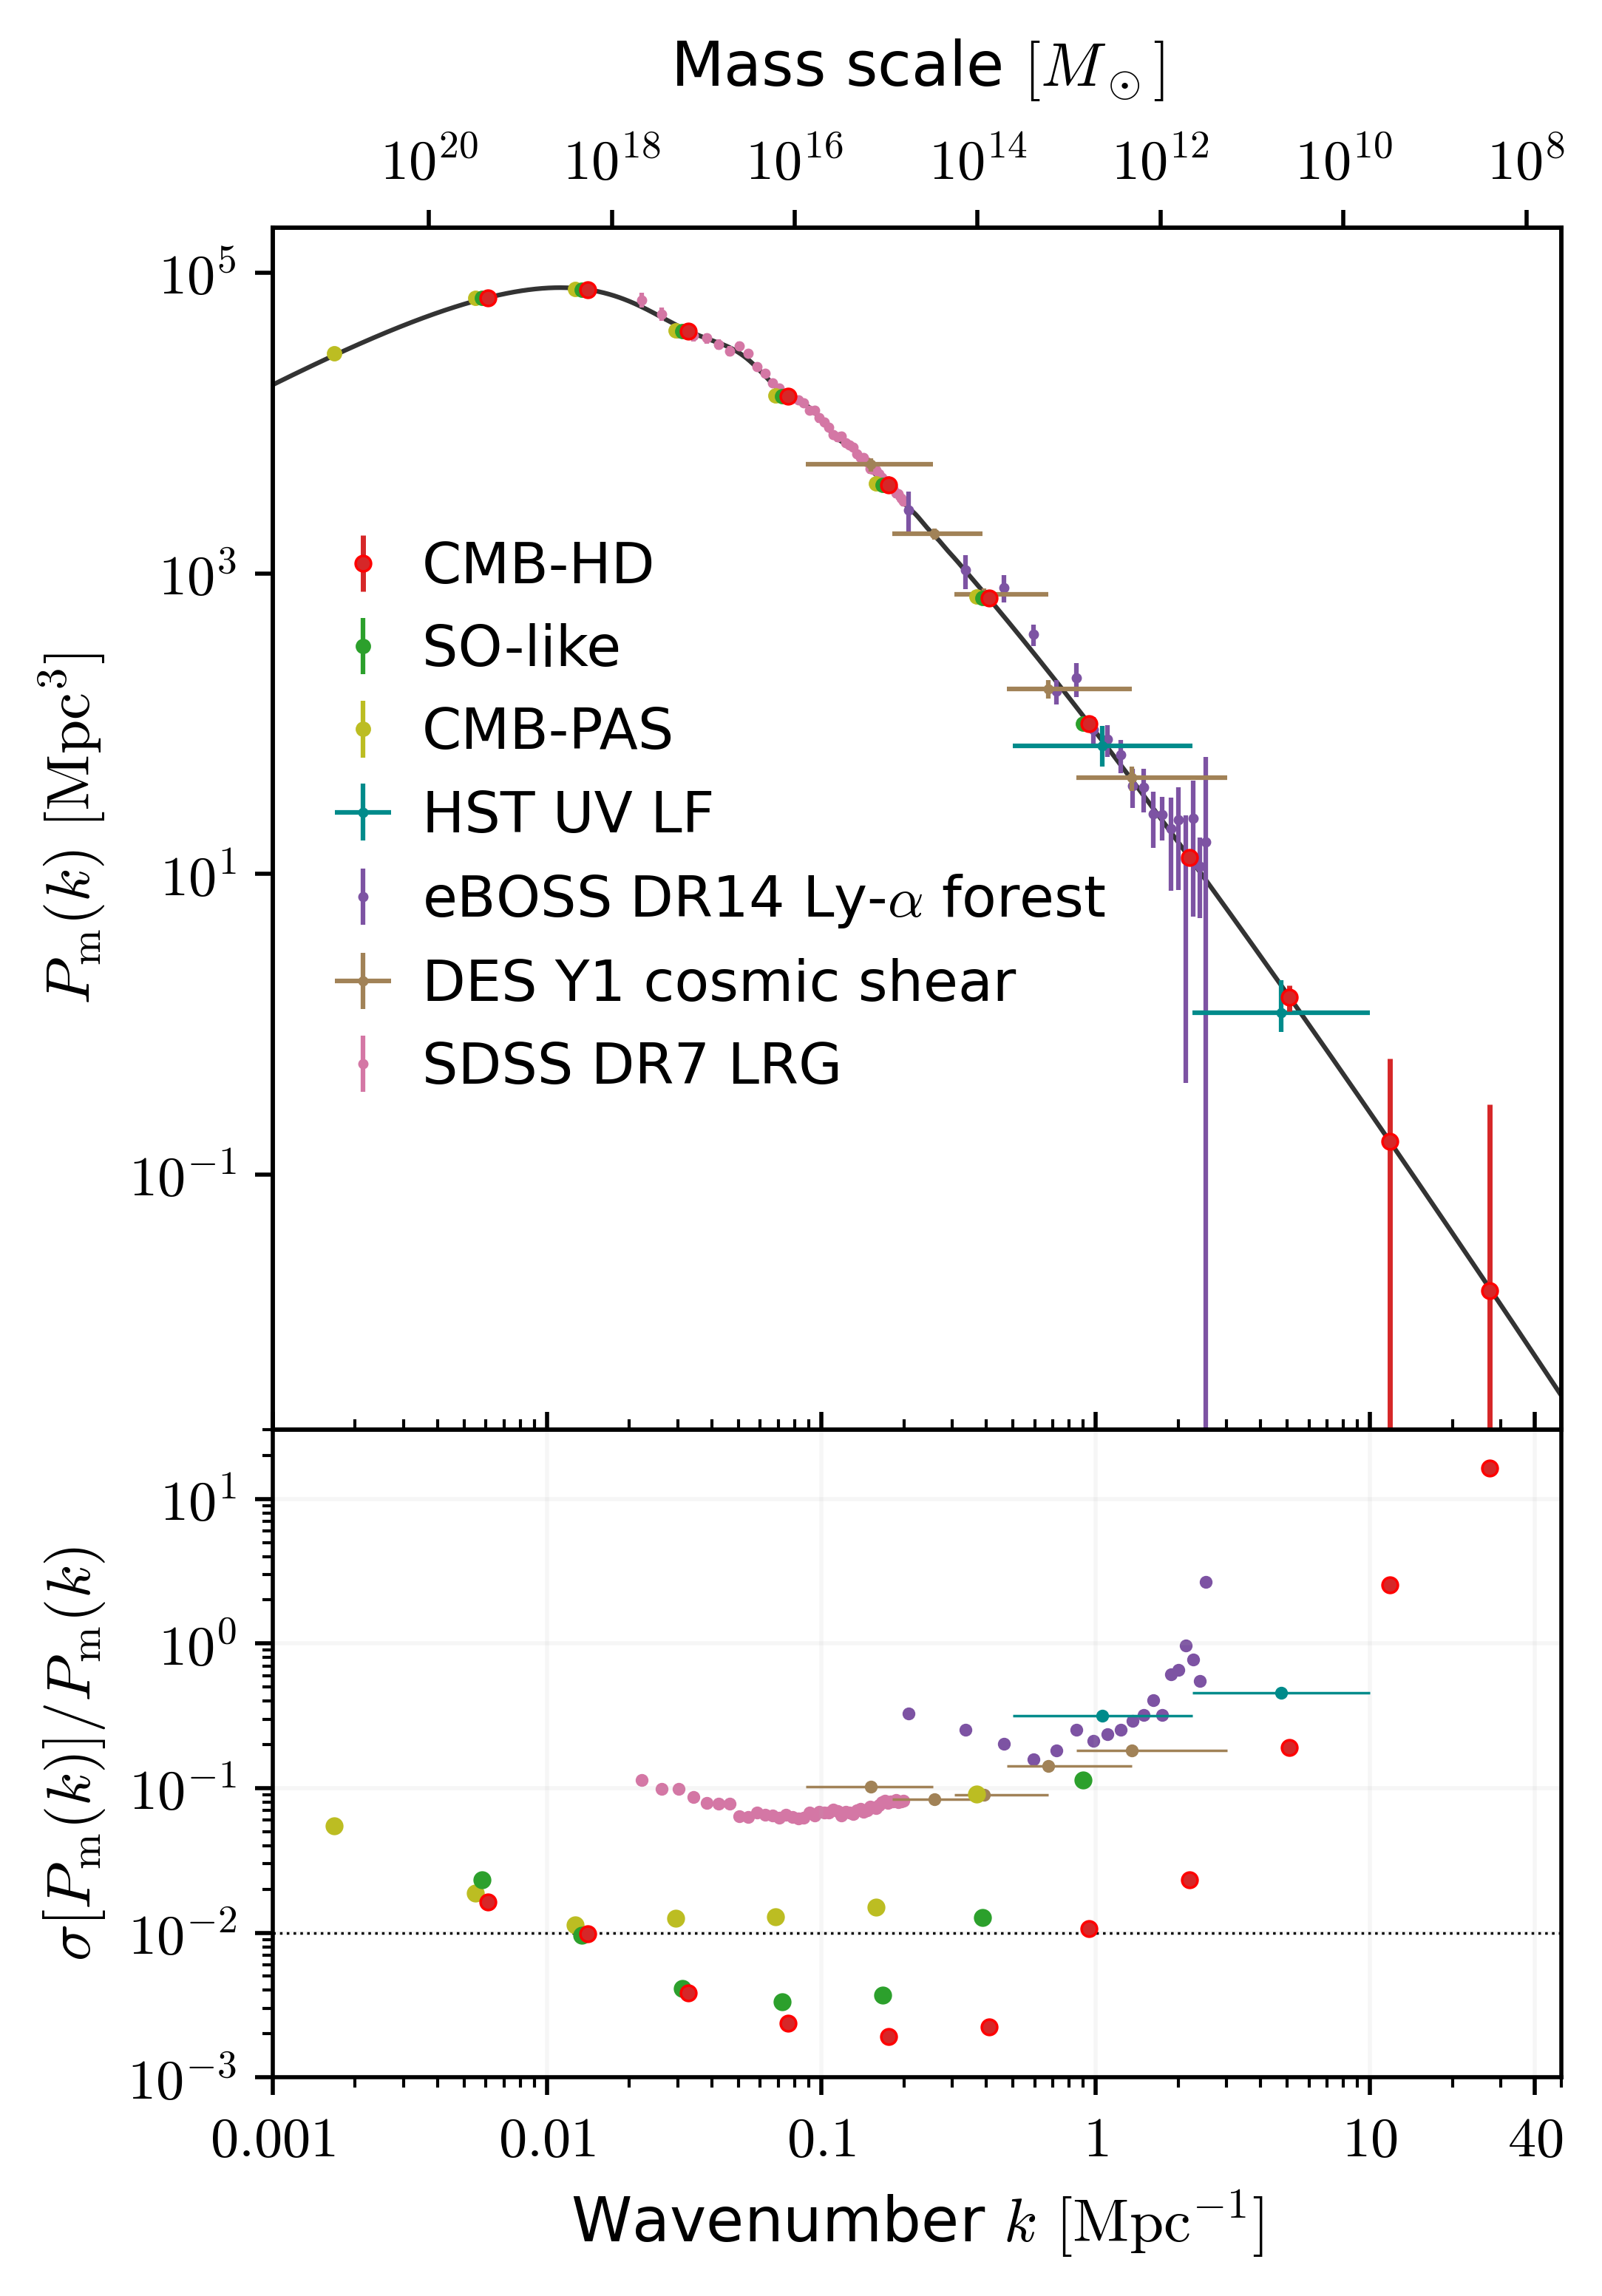

In [41]:
mpk_marker = '.'
mpk_mew = 0.5
mpk_markersize = {key: 3 for key in mpk_data_set_names}
mpk_markersize['so'] = 5
mpk_markersize['pas'] = 5
mpk_markersize['hd'] = 6
mpk_elw = 0.9
mpk_alpha = 1
plt.rcParams['mathtext.fontset'] = 'cm'

fig6_xmin, fig6_xmax = 1e-3, 50
fig6_xticks = [10**i for i in range(-3, 3)]
fig6_xticks[-1] = 40

fig, (ax, ax3) = plt.subplots(figsize=(4.5, 6.5), nrows=2,
                              height_ratios=[0.65, 0.35], dpi=500, facecolor='w')

# --- top panel: P_m(k) ---
ax.margins(0.1)
ax.plot(theo_ks, theo_Pks, color='k', alpha=0.8, lw=0.9, zorder=-10)

# CMB-HD:
ax.errorbar(mpk_ks['hd'], mpk_Pks['hd'], yerr=mpk_Pk_errs['hd'],
            label=mpk_labels['hd'], color=mpk_colors['hd'],
            zorder=mpk_zorders['hd'], ls='none', marker=mpk_marker,
            markeredgewidth=mpk_mew, markeredgecolor='r',
            markersize=mpk_markersize['hd'], elinewidth=1)

for key in mpk_data_set_names[1:]:
    yerr = ([mpk_Pk_lower_errs[key], mpk_Pk_upper_errs[key]]
            if key in mpk_Pk_upper_errs else mpk_Pk_errs[key])
    xerr = mpk_k_errs[key] if key in mpk_k_errs else None
    ax.errorbar(mpk_ks[key], mpk_Pks[key], yerr=yerr, xerr=xerr,
                label=mpk_labels[key], zorder=mpk_zorders.get(key),
                color=mpk_colors[key], alpha=mpk_alpha, marker=mpk_marker,
                markeredgewidth=mpk_mew, markersize=mpk_markersize[key],
                elinewidth=mpk_elw, ls='none')

ax.set_xlim([fig6_xmin, fig6_xmax])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$P_\mathrm{m}(k)~[{\rm Mpc}^3]$', fontsize=12)
ax.set_xticks(fig6_xticks)
ax.set_xticklabels(['' for _ in fig6_xticks])
ytick_exps = [-3, -1, 1, 3, 5]
ax.set_yticks([10**e for e in ytick_exps])
ax.set_yticklabels([r'$10^{%d}$' % e for e in ytick_exps])
ax.tick_params(labelsize=11)
ax.tick_params(axis='x', direction='in', which='both')
ax.set_ylim([2e-3, 2e5])

# top mass-scale axis:
ax2 = ax.twiny()
ax2.set_xlim([fig6_xmin, fig6_xmax])
ax2.set_xlabel(r'Mass scale $[M_\odot]$', fontsize=12, labelpad=10)
ax2.set_xscale('log')
ax2.minorticks_off()
M_exps = list(range(8, 25, 2))[::-1]
ax2.set_xticks([k_c(10**e) for e in M_exps], minor=False)
ax2.set_xticklabels([r'$10^{%d}$' % e for e in M_exps], fontsize=11,
                    fontfamily='dejavusans')

# --- bottom panel: fractional error ---
ax3.margins(0.1)
ax3.errorbar(mpk_ks['hd'], mpk_Pk_errs['hd'] / mpk_Pks['hd'],
             color=mpk_colors['hd'], zorder=mpk_zorders['hd'], ls='none',
             marker=mpk_marker, markeredgewidth=mpk_mew, markeredgecolor='r',
             markersize=mpk_markersize['hd'], elinewidth=1)
for key in mpk_data_set_names[1:]:
    pk_errs = mpk_Pk_errs[key]
    if hasattr(pk_errs, 'shape') and len(np.shape(pk_errs)) > 1:
        pk_errs = (np.asarray(pk_errs[1]) + np.asarray(pk_errs[0])) / 2
    xerr = mpk_k_errs[key] if key in mpk_k_errs else None
    ax3.errorbar(mpk_ks[key], np.asarray(pk_errs) / mpk_Pks[key], xerr=xerr,
                 label=mpk_labels[key], zorder=mpk_zorders.get(key),
                 color=mpk_colors[key], alpha=mpk_alpha, marker=mpk_marker,
                 markeredgewidth=mpk_mew, markersize=mpk_markersize[key] + 1,
                 elinewidth=0.5, ls='none')

ax3.axhline(y=0.01, color='k', ls=':', lw=0.5)
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.grid(alpha=0.1)
ax3.set_xticks(fig6_xticks)
ax3.set_xticklabels([r'$%s$' % str(tick) for tick in fig6_xticks])
ax3.set_xlim([fig6_xmin, fig6_xmax])
ax3.set_xlabel(r'Wavenumber $k$ $[{\rm Mpc}^{-1}]$', fontsize=12)
ax3_exps = [-3, -2, -1, 0, 1]
ax3.set_yticks([10**e for e in ax3_exps])
ax3.set_ylim(10**-3, 30)
ax3.set_yticklabels([r'$10^{%d}$' % e for e in ax3_exps])
ax3.set_ylabel(r'$\sigma\left[P_\mathrm{m}(k)\right] / P_\mathrm{m}(k)$',
               fontsize=12)
ax3.tick_params(labelsize=11)

for plt_ax in [ax, ax2, ax3]:
    plt_ax.set_xlim([fig6_xmin, fig6_xmax])

ax.legend(frameon=False, loc='lower left', bbox_to_anchor=(0, 0.25),
          handletextpad=0.05, borderpad=0.1)
plt.subplots_adjust(hspace=0)
save_figure('fig6', bbox_inches='tight', dpi=500)
print('CMB-HD fractional errors:', mpk_Pk_errs['hd'] / mpk_Pks['hd'])
plt.show()

# restore the default mathtext font for the remaining figures:
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# Setup for the bias calculation (Figures 7 and 8)

We estimate the bias induced on the cosmological parameters when the
spectra are computed with insufficient Boltzmann-code accuracy settings,
following the standard linear bias formula
$b_i = (F^{-1})_{ij} \, \partial_j C^T \, \mathrm{Cov}^{-1} \, (C^\mathrm{true} - C^\mathrm{fid})$.

Note that the spectra needed for the bias calculation (other than the
fiducial CAMB ones) cannot be run on a login node and must be generated
with a job on a compute node.

In [42]:
def calc_bias(fid_spec, true_spec, covmat, derivs, fisher_matrix):
    """Take in the components of the bias equation and calculate the bias.

    Args:
        fid_spec (numpy array): 1d np array of the binned fiducial spectra,
            concatenated in order TT, TE, EE, BB, kk
        true_spec (numpy array): 1d np array of the binned true universe
            spectra, concatenated in order TT, TE, EE, BB, kk
        covmat (numpy array): a 2d array containing the CMB-HD covmat
        derivs (numpy array): an nd array (where n is the number of params)
            of the derivatives of the spectra with respect to each param.
            The derivs should be binned and concatenated in the same spectra
            order as the true/fid spec, and should have the same params in
            the same order as the fisher matrix.
        fisher_matrix (numpy array): a n x n fisher matrix, where n is the
            number of params.

    Returns:
        bias (np array): A 1d array of the biases on each parameter, in the
            same order as the params in the fisher matrix/derivs.
    """
    difference = true_spec - fid_spec
    first_product = np.linalg.solve(covmat, difference)
    second_product = derivs @ first_product
    bias = np.linalg.solve(fisher_matrix, second_product)
    return bias


def order_spectra(spectra):
    """Take in a dict of spectra and return a concatenated array of spectra
    in order TT, TE, EE, BB, kk.

    Args:
        spectra: a dictionary containing the spectra, with keys 'tt', 'te',
            'ee', 'bb', 'kk'.

    Returns:
        (np array): The spectra concatenated into a 1d array in order
            TT, TE, EE, BB, kk.
    """
    return np.concatenate([
        spectra['tt'],
        spectra['te'],
        spectra['ee'],
        spectra['bb'],
        spectra['kk']])


def order_derivs(derivs, param_order):
    """Take in a dict of derivs of spectra and return them in the order
    `param_order`, spectra concatenated in TT, TE, EE, BB, kk.

    Args:
        derivs (dictionary of np arrays): A dict of the derivs of the power
            spectra with respect to each param. Should be in the format of
            [param][spectra type] where the spectra types are 'tt', 'te',
            'ee', 'bb', 'kk'.
        param_order (list of strings): A list of the parameters, in the
            order the function should output derivs in.

    Returns:
        final_derivs (np array): an nd array of the concatenated derivatives
            with shape (num params, num bins).
    """
    derivs_cat = [order_spectra(derivs[p]) for p in param_order]
    final_derivs = np.stack(derivs_cat)
    return final_derivs


def bin_spec(cl, matrix, lmax):
    """Take in a dict of unbinned spectra, the binning matrix, and the
    maximum ell to go to, and return the binned spectra.

    Args:
        cl (dictionary): A dict containing the unbinned spectra. Should have
            keys 'tt', 'te', 'ee', 'bb', 'kk'.
        matrix: The binning matrix to be used to bin the data.
        lmax: The maximum ell of the binning matrix, to cut the spectra at.

    Returns:
        binned_cl (dictionary): a dictionary of the binned spectra.
    """
    slice_end = lmax + 1
    binned_cl = {'tt': (matrix @ cl['tt'][2:slice_end]),
                 'te': (matrix @ cl['te'][2:slice_end]),
                 'ee': (matrix @ cl['ee'][2:slice_end]),
                 'bb': (matrix @ cl['bb'][2:slice_end]),
                 'kk': (matrix @ cl['kk'][2:slice_end])}
    return binned_cl

In [43]:
fisher_derivs_path = hdinitpk.external_data_path('fisher_derivs')
print(f'loading the Fisher derivatives from {fisher_derivs_path}')

use_H0 = True
use_new_covmats = True
kk_lmax_cut = 20100

# The Fisher libraries are only needed here to load the saved CMB
# derivatives (`load_cmb_fisher_derivs`), with `overwrite=False` so the
# saved derivatives are reused rather than recomputed; the matrices
# themselves are loaded from the packaged data directory below. The
# step-size and fiducial-parameter YAML files ship with the package.
camb_fisherlib = fisher.Fisher(
    os.path.join(fisher_derivs_path, 'camb_fisher_output_kmax_100_new_delensing'),
    overwrite=False, use_H0=use_H0, use_class=False,
    external_covmat=use_new_covmats, external_hd_kk_lmax=kk_lmax_cut,
    fisher_steps_file=hdinitpk.data_path('fisher_steps',
                                         'camb_fiducial_step_sizes.yaml'),
    param_file=hdinitpk.data_path('fisher_fid_params',
                                  'kmax_100_camb_fiducial_params.yaml'))

class_fisherlib = fisher.Fisher(
    os.path.join(fisher_derivs_path, 'new_class_fisher_output_class_desi'),
    overwrite=False, use_H0=use_H0, use_class=True,
    external_covmat=use_new_covmats, external_hd_kk_lmax=kk_lmax_cut,
    fisher_steps_file=hdinitpk.data_path('fisher_steps',
                                         'class_fiducial_step_sizes.yaml'),
    param_file=hdinitpk.data_path('fisher_fid_params',
                                  'class_fiducial_params.yaml'))

loading the Fisher derivatives from /gpfs/projects/SehgalGroup/zcheslog/cmb_hd/hdinitPk/external_data/fisher_derivs


/gpfs/home/zcheslog/.local/lib/python3.11/site-packages/hdfisher/fisher.py:923: UserWarning: `external_covmat=True`: cutting the CMB-HD lensing (kk) binning range at Lmax=20100 to match the external covariance matrix (TT/TE/EE/BB are unchanged).
  warnings.warn(msg)
/gpfs/home/zcheslog/.local/lib/python3.11/site-packages/hdfisher/fisher.py:900: UserWarning: `use_class=True`: delensed spectra are not calculated with CLASS. No delensed derivatives will be calculated, and a Fisher matrix cannot be calculated from delensed spectra. Use `cmb_type='lensed'`, or set `use_class=False` to use CAMB.
  warnings.warn(msg)


In [44]:
# Binning matrix and CMB-HD covariance matrix used in the bias calculation:
binning_matrix = hd_datalib.binning_matrix(lmin=30, lmax=20100)

# Updated (2026-06-22) lensed CMB-HD covariance matrix, for the binned
# TT, TE, EE, BB, and kk spectra in that order. Its size must match the
# length of the concatenated binned spectrum vector built by
# `order_spectra` below, i.e. five times the number of bins in
# `binning_matrix`.
#
# TEMPORARY: this v1.2 covariance matrix is loaded from an absolute path on
# SeaWulf, because it is not yet distributed anywhere. It will ship with
# the `hd_mock_data` repository when this goes live, at which point this
# cell should load it through `hd_datalib` instead of by path -- see the
# commented-out `load_cmb_covmat` call below.
bias_covmat_file = ('/gpfs/projects/SehgalGroup/shared/covmats_08_05_2026/hd_v1.2_lmin30lmax20100Lmax20100_lensed_covmat.txt')
covmat = np.loadtxt(bias_covmat_file)
print(f'covariance matrix: {covmat.shape}, '
      f'expected ({5 * binning_matrix.shape[0]}, {5 * binning_matrix.shape[0]})')

# Once the v1.2 covmat is part of hd_mock_data, replace the two lines above
# with something like:
#covmat = hd_datalib.load_cmb_covmat('HD', cmb_type='lensed')

covariance matrix: (515, 515), expected (515, 515)


In [45]:
# Fisher matrices and errors with eight parameters (the bias calculation
# fixes the running), from the packaged data directory. The CLASS file keeps native
# CLASS parameter names, translated here:
eight_param_camb_fisher_matrix_with_desi = load_saved_fisher('hd_camb_lensed_8param')
eight_param_errs_with_desi_camb = fisher.get_fisher_errors(
    *eight_param_camb_fisher_matrix_with_desi)

eight_param_class_fisher_matrix_with_desi = from_class_fisher(
    load_saved_fisher('hd_class_lensed_8param'))
eight_param_errs_with_desi_class = fisher.get_fisher_errors(
    *eight_param_class_fisher_matrix_with_desi)


In [46]:
# Load in the CAMB/CLASS Fisher derivatives:
camb_derivs = camb_fisherlib.load_cmb_fisher_derivs(binned=True)
class_derivs = from_class_derivs(
    class_fisherlib.load_cmb_fisher_derivs(cmb_types=['lensed'], binned=True))

UnboundLocalError: cannot access local variable 'ells' where it is not associated with a value

In [ ]:
# Load in the spectra. The "true universe" spectra are high-accuracy CAMB
# spectra; the CAMB and CLASS spectra are computed over a grid of accuracy
# settings (`lens_potential_accuracy` for CAMB, `P_k_max_h/Mpc` for CLASS).
# These ship with the package, under `<data>/spectra_for_bias`.
spectra_path = hdinitpk.data_path('spectra_for_bias')

true_spectra = utils.load_from_file(
    os.path.join(spectra_path, 'lensed_lmax=24000_true_universe_spectra.txt'),
    ['tt', 'te', 'ee', 'bb', 'kk'])

P_k_max_values = [50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
lens_potential_values = [8, 10, 15, 20, 25, 30, 35, 40]
camb_spectra = {}
class_spectra = {}
for p in lens_potential_values:  # CAMB
    camb_spectra[p] = utils.load_from_file(
        os.path.join(spectra_path, 'camb',
                     f'lensed_lmax=24000_lens_potential_accuracy={p}_camb_spectra.txt'),
        ['tt', 'te', 'ee', 'bb', 'kk'])
for p in P_k_max_values:  # CLASS
    class_spectra[p] = utils.load_from_file(
        os.path.join(spectra_path, 'class',
                     f'lensed_lmax=24000_P_k_max_h_Mpc={p}_class_spectra.txt'),
        ['tt', 'te', 'ee', 'bb', 'kk'])

# Figure 7

Ratio of the binned CAMB and CLASS spectra at the accuracy settings adopted
for the paper (`lens_potential_accuracy=30` for CAMB and
`P_k_max_h/Mpc=500` for CLASS).

In [ ]:
binning_matrix_lmax_24000 = hd_datalib.binning_matrix(lmin=30, lmax=24000)
binned_camb_24000 = bin_spec(camb_spectra[30], binning_matrix_lmax_24000, 24000)
binned_class_24000 = bin_spec(class_spectra[500], binning_matrix_lmax_24000, 24000)
binned_ells = binning_matrix_lmax_24000 @ np.arange(2, 24001)

binned_ratio = {}
for s in ['tt', 'te', 'ee', 'bb', 'kk']:
    binned_ratio[s] = binned_camb_24000[s] / binned_class_24000[s]

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

spectra_labels = {'tt': 'TT', 'ee': 'EE', 'bb': 'BB', 'kk': r'$\kappa \kappa$'}
for s in ['tt', 'ee', 'bb', 'kk']:
    ax.plot(binned_ells, binned_ratio[s], label=spectra_labels[s], linewidth=1.5)

ax.set_xlabel(r'$\ell$', fontsize=16)
ax.set_ylabel(r'$C_\ell^{\mathrm{CAMB}} \ / \ C_\ell^{\mathrm{CLASS}}$', fontsize=16)
ax.legend(fontsize=14)
plt.xlim(0, 24000)
plt.tight_layout()
ax.grid(which='major', linestyle='-', linewidth=0.6, color='0.85')
save_figure('fig7')
plt.show()

## Bias calculation

In [ ]:
# Bin and concatenate the spectra, then compute the bias at each accuracy
# setting.
binned_true = bin_spec(true_spectra, binning_matrix, 20100)
cat_true_spec = order_spectra(binned_true)

# concatenate the derivs in the Fisher-matrix parameter order:
ordered_camb_derivs = order_derivs(
    camb_derivs[1]['lensed'], eight_param_camb_fisher_matrix_with_desi[1])
ordered_class_derivs = order_derivs(
    class_derivs[1]['lensed'], eight_param_class_fisher_matrix_with_desi[1])

camb_bias = {}
class_bias = {}
for p in lens_potential_values:  # CAMB
    cat_camb_spec = order_spectra(bin_spec(camb_spectra[p], binning_matrix, 20100))
    camb_bias[p] = calc_bias(cat_camb_spec, cat_true_spec, covmat,
                             ordered_camb_derivs,
                             eight_param_camb_fisher_matrix_with_desi[0])
for p in P_k_max_values:  # CLASS
    cat_class_spec = order_spectra(bin_spec(class_spectra[p], binning_matrix, 20100))
    class_bias[p] = calc_bias(cat_class_spec, cat_true_spec, covmat,
                              ordered_class_derivs,
                              eight_param_class_fisher_matrix_with_desi[0])

In [ ]:
# Divide the bias by the forecasted error on each parameter:
camb_bias_over_error = {}
class_bias_over_error = {}
for i, p in enumerate(eight_param_camb_fisher_matrix_with_desi[1]):
    camb_bias_over_error[p] = [camb_bias[a][i] / eight_param_errs_with_desi_camb[p]
                               for a in lens_potential_values]
for i, p in enumerate(eight_param_class_fisher_matrix_with_desi[1]):
    class_bias_over_error[p] = [class_bias[a][i] / eight_param_errs_with_desi_class[p]
                                for a in P_k_max_values]

camb_bias_over_error['lens_potential_accuracy'] = lens_potential_values
class_bias_over_error['P_k_max_h/Mpc'] = P_k_max_values
bias_plt_data = {'camb': camb_bias_over_error, 'class': class_bias_over_error}

# Figure 8

Bias/error on each parameter as a function of the CAMB and CLASS accuracy
settings.

In [ ]:
# parameters to plot, and the order to plot them in:
fig8_params = ['mnu', 'tau', 'logA', 'H0', 'ombh2', 'omch2', 'ns', 'nnu']
fig8_param_labels = {p: f'${param_labels[p]}$' for p in fig8_params}
fig8_colors = {'mnu': 'g', 'tau': 'tab:grey', 'logA': 'y', 'H0': 'b',
               'ombh2': 'tab:brown', 'omch2': 'tab:pink', 'ns': 'm', 'nnu': 'r'}

# x-axis for CAMB or CLASS:
accuracy_param = {'camb': 'lens_potential_accuracy', 'class': 'P_k_max_h/Mpc'}
fig8_xlabels = {'camb': r'$\mathtt{lens\_potential\_accuracy}$',
                'class': r'$\mathtt{P\_k\_max\_h/Mpc}$'}
fig8_xticks = {'camb': [8, *range(10, 45, 5)], 'class': [50, *range(200, 1200, 200)]}

# text box to label CAMB or CLASS:
txt_bbox = {'edgecolor': 'k', 'facecolor': 'w', 'alpha': 0.85, 'lw': 1.5,
            'boxstyle': 'round', 'pad': 0.4}
txt_kwargs = {'fontsize': 18, 'va': 'top', 'ha': 'center', 'bbox': txt_bbox}

fig, axs = plt.subplots(figsize=(12, 5), dpi=300, ncols=2)

for i, key in enumerate(['camb', 'class']):
    ax = axs[i]
    xvals = bias_plt_data[key][accuracy_param[key]]

    ax.margins(0.025)
    for param in fig8_params:
        ax.plot(xvals, bias_plt_data[key][param], '.-', lw=1,
                label=fig8_param_labels[param], color=fig8_colors[param])

    ax.text(0.3, 0.9, key.upper(), transform=ax.transAxes, **txt_kwargs)
    ax.legend(fontsize=14)
    ax.set_xticks(fig8_xticks[key])
    ax.set_xlabel(fig8_xlabels[key], fontsize=16)
    ax.set_ylabel('Bias / Error', fontsize=16)
    ax.tick_params(labelsize=12)
    ax.grid(alpha=0.25)

save_figure('fig8')
plt.show()

# Figure 9

Validation of the Fisher forecasts against full MCMC chains: triangle plot
of the CAMB and CLASS Fisher forecasts versus the corresponding (thinned)
CAMB and CLASS MCMC chains, for CMB-HD + DESI BAO in the 9-parameter model.

In [ ]:
def reorder_fisher_matrix(fisher_matrix, original_order, target_order):
    """Reorders the Fisher matrix from `original_order` to `target_order`.

    Args:
        fisher_matrix (ndarray): The Fisher matrix to reorder.
        original_order (list): Current order of parameter names.
        target_order (list): Desired order of parameter names.

    Returns:
        ndarray: Reordered Fisher matrix.
    """
    index_map = [original_order.index(param) for param in target_order]
    return fisher_matrix[np.ix_(index_map, index_map)]

In [ ]:
# CAMB MCMC chain (CMB-HD + DESI BAO, 9 parameters), thinned
# (burn-in already removed):
camb_mcmc_samples = load_thinned_chain('hd_camb_mcmc_9param')
camb_mcmc_samples.paramNames.parWithName('nrun').label = r'\alpha_\mathrm{s}'
print('R-1 = ', chain_convergence.get('hd_camb_mcmc_9param', float('nan')),
      '(full chain)')

# parameter names (sampled and derived), excluding the chi2 and prior
# bookkeeping columns:
camb_chain_params = [p.name for p in camb_mcmc_samples.getParamNames().names
                     if ('chi2' not in p.name) and ('minuslogprior' not in p.name)]
camb_mcmc_means = {}
camb_mcmc_errors = {}
camb_mstats = camb_mcmc_samples.getMargeStats()
for param in camb_chain_params:
    par = camb_mstats.parWithName(param)
    camb_mcmc_means[param] = par.mean
    camb_mcmc_errors[param] = par.err
print(camb_mcmc_means)
print(camb_mcmc_errors)


In [ ]:
# CLASS MCMC chain, thinned as above. The chain columns
# use native CLASS/cobaya names (note 'N_eff', unlike the 'Neff' used by the
# Fisher parameter files), so we use a separate translation dictionary from
# the Fisher one above.
camb_to_class_chain_params = {
    'ombh2': 'omega_b',
    'omch2': 'omega_cdm',
    'tau': 'tau_reio',
    'logA': 'ln_A_s_1e10',
    'As': 'A_s',
    'ns': 'n_s',
    'H0': 'H0',
    'nnu': 'N_eff',
    'mnu': 'mnu',
    'nrun': 'alpha_s',
}

class_mcmc_samples = load_thinned_chain('hd_class_mcmc_9param')
class_mcmc_samples.paramNames.parWithName('nrun').label = r'\alpha_\mathrm{s}'

# add CAMB-named aliases for a few CLASS parameters, so getdist can match
# them across the four sets of samples in the triangle plot:
for param in ['logA', 'nnu', 'ombh2', 'omch2']:
    class_name = camb_to_class_chain_params[param]
    class_mcmc_samples.addDerived(
        getattr(class_mcmc_samples.getParams(), class_name),
        param, label=param_labels[param])

print('R-1 = ', chain_convergence.get('hd_class_mcmc_9param', float('nan')),
      '(full chain)')

class_chain_params = [p.name for p in class_mcmc_samples.getParamNames().names
                      if ('chi2' not in p.name) and ('minuslogprior' not in p.name)]
class_mcmc_means = {}
class_mcmc_errors = {}
class_mstats = class_mcmc_samples.getMargeStats()
for param in class_chain_params:
    par = class_mstats.parWithName(param)
    class_mcmc_means[param] = par.mean
    class_mcmc_errors[param] = par.err
print(class_mcmc_means)
print(class_mcmc_errors)


In [ ]:
# Reorder the Fisher matrices into the plotting order:
print(class_fisher_matrix_with_desi[1])
print(camb_fisher_matrix_with_desi[1])
reordered_class_fisher_matrix_with_desi = reorder_fisher_matrix(
    class_fisher_matrix_with_desi[0], class_fisher_matrix_with_desi[1], nine_params)
reordered_camb_fisher_matrix_with_desi = reorder_fisher_matrix(
    camb_fisher_matrix_with_desi[0], camb_fisher_matrix_with_desi[1], nine_params)

In [ ]:
# Fiducial parameter values used to center the Fisher contours and to mark
# the fiducial point in the triangle plot. (The chain files include the
# cobaya-named 'omegabh2'/'omegach2' aliases.)
fig9_fid_params = {'ombh2': 0.02237,
                   'omch2': 0.1200,
                   'omegabh2': 0.02237,
                   'omegach2': 0.1200,
                   'ns': 0.9649,
                   'logA': 3.044,
                   'As': np.exp(3.044) * 1.e-10,
                   'H0': 67.36,
                   'tau': 0.0544,
                   'nnu': 3.044,
                   'mnu': 0.06,
                   'HMCode_logT_AGN': 7.8,
                   'nrun': 0.0,
                   'A_ksz': 1.0,
                   'n_ksz': 0.0}

camb_fisher_samples = getdist_samples(reordered_camb_fisher_matrix_with_desi,
                                      nine_params, fig9_fid_params)
class_fisher_samples = getdist_samples(reordered_class_fisher_matrix_with_desi,
                                       nine_params, fig9_fid_params)

In [ ]:
fig9_colors = ['tab:pink', 'tab:cyan', 'tab:red', 'tab:blue']
fig9_filled = [True, True, False, False]
fig9_ls = ['-', '--', ':', ':']
fig9_lw_1d = [1.5, 1.5, 1.5, 1.5]
fig9_lw = [1.5, 1.5, 1.2, 1.2]
fig9_legend_labels = ['CAMB Fisher', 'CLASS Fisher', 'CAMB MCMC', 'CLASS MCMC']

plt.rcParams['legend.title_fontsize'] = 13

g = plots.get_subplot_plotter(width_inch=6.5)
g.settings.scaling_factor = 1.1
g.settings.legend_fontsize = 14
g.settings.axes_fontsize = 11
g.settings.axes_labelsize = 12
g.settings.constrained_layout = True
g.settings.figure_legend_frame = False
g.triangle_plot([camb_fisher_samples, class_fisher_samples,
                 camb_mcmc_samples, class_mcmc_samples],
                params=nine_params,
                filled=fig9_filled, param_limits={'mnu': [0, 0.17]},
                diag1d_kwargs={'lws': fig9_lw_1d, 'ls': fig9_ls},
                contour_colors=fig9_colors,
                contour_args=[{'alpha': 0.75}, {'alpha': 0.75},
                              {'alpha': 1.0}, {'alpha': 1.0}],
                ls=fig9_ls, lws=fig9_lw,
                legend_loc='upper right',
                legend_labels=fig9_legend_labels, markers=fig9_fid_params)
g.legend.set_title(r'CMB-HD + DESI BAO')

# reduce the tick clutter in the ns column:
g.subplots[-1, 6].set_xticks([0.965])

plt.gcf().set_dpi(500)
save_figure('fig9')
plt.show()

plt.rcParams['legend.title_fontsize'] = None

In [ ]:
# Compare the Fisher and MCMC error bars (CAMB and CLASS):
class_mcmc_errors_camb_names = {}
for p in errs_with_desi_camb.keys():
    class_mcmc_errors_camb_names[p] = class_mcmc_errors[camb_to_class_chain_params[p]]

table_list = [errs_with_desi_camb, camb_mcmc_errors,
              ratio(errs_with_desi_camb, camb_mcmc_errors),
              errs_with_desi_class, class_mcmc_errors_camb_names,
              ratio(errs_with_desi_class, class_mcmc_errors_camb_names)]
label_list = ['CAMB + DESI fisher', 'CAMB + DESI MCMC',
              'CAMB Ratio (Fisher/MCMC)', 'CLASS + DESI fisher',
              'CLASS + DESI MCMC', 'CLASS Ratio (Fisher/MCMC)']
print_table(table_list, label_list, list_of_keys=nine_params)

In [ ]:
# Emit the LaTeX body rows (between \midrule and \bottomrule) for the
# CAMB/CLASS Fisher-vs-MCMC error comparison table. The input dicts are all
# keyed by CAMB parameter names; the ratio columns are computed from them.
fisher_mcmc_row_order = ['ombh2', 'omch2', 'H0', 'tau', 'logA', 'ns',
                         'nrun', 'nnu', 'mnu']


def fisher_mcmc_table_rows(camb_fisher, class_fisher, camb_mcmc, class_mcmc,
                           order=fisher_mcmc_row_order,
                           sig_figs=err_sig_figs, rdec=ratio_decimals):
    """Return the LaTeX `tabular` body (one '... \\\\' line per parameter)."""
    lines = []
    for p in order:
        n = sig_figs[p]
        r = f'{{:.{rdec}f}}'             # ratio format (fixed decimals)
        cf, clf = camb_fisher[p], class_fisher[p]
        cm, clm = camb_mcmc[p], class_mcmc[p]
        cells = [
            f'${param_labels[p]}$' + r'\dotfill',   # col 1: parameter
            sigfig(cf, n),               # col 2: CAMB Fisher
            sigfig(clf, n),              # col 3: CLASS Fisher
            '',                          # col 4: spacer
            r.format(cf / clf),          # col 5: CAMB / CLASS Fisher ratio
            '',                          # col 6: spacer
            sigfig(cm, n),               # col 7: CAMB MCMC
            sigfig(clm, n),              # col 8: CLASS MCMC
            '',                          # col 9: spacer
            r.format(cf / cm),           # col 10: Fisher/MCMC CAMB
            r.format(clf / clm),         # col 11: Fisher/MCMC CLASS
        ]
        lines.append(' & '.join(cells) + r' \\')
    return '\n'.join(lines)


print(fisher_mcmc_table_rows(errs_with_desi_camb, errs_with_desi_class,
                             camb_mcmc_errors, class_mcmc_errors_camb_names))

# Figure 10

Binned $e^{-2\tau} \mathcal{P}(k)$ constraints with finer (30-bin) binning,
compared to the official P-ACT-LB binned-P(k) chain.

In [ ]:
# The marginalized statistics of the 30-bin chains (including the official
# P-ACT-LB chain) were loaded in Part 1. Here, load the 62-bin (kmax = 50)
# binning they use (k bin centers, fiducial P(k), and bin edges):
ks_62bin, pk_62bin = np.loadtxt(
    os.path.join(binning_data_path, 'binning_62bins.txt'), unpack=True)
bin_edges_62 = np.loadtxt(
    os.path.join(binning_data_path, 'act_bin_edges_kmax50.txt'))

In [ ]:
fig10_legend_kwargs = {
    'frameon': False,
    'fontsize': legend_fontsize,
    'loc': 'upper left',
    'bbox_to_anchor': (0, 1),
    'ncol': 2,
    'columnspacing': 0.65,
    'handletextpad': 0.5,
    'handlelength': 1.0,
    'markerscale': 1.5,
    'borderpad': 0,
}

plt_kmin, plt_kmax = 5e-5, 5.5e-1
plt_ymin, plt_ymax = 0.9, 7

ks_extended_30bin = np.logspace(np.log10(plt_kmin), np.log10(plt_kmax), 500)
hd_pk_extended_30bin = [1e9 * np.exp(-2 * tau) * hd_Pk(k) for k in ks_extended_30bin]

fig, (ax_main, ax_frac) = plt.subplots(
    2, 1, figsize=(4.5, 6.5), dpi=500, facecolor='w', sharex=True,
    gridspec_kw={'height_ratios': [0.65, 0.35], 'hspace': 0.03})

ks_chains_30bin = ks_62bin[0:30]

fig10_sample_sets = [
    ('P-ACT-LB', p_act_means_30bin, p_act_asymmetric_errors_30bin, 'tab:grey'),
    ('CMB-PAS', pas_means_30bin, pas_asymmetric_errors_30bin, 'goldenrod'),
    ('CMB-PAS+DESI', pas_desi_means_30bin, pas_desi_asymmetric_errors_30bin, 'tab:cyan'),
]

# --- main panel ---
set_loglog(ax_main)
ax_main.plot(ks_extended_30bin, hd_pk_extended_30bin, linestyle='-',
             color='tab:gray', linewidth=1, zorder=1, label='Theory')
for label, means, (lower_errs, upper_errs), color in fig10_sample_sets:
    add_box_errors(ax_main, ks_chains_30bin, means, lower_errs, upper_errs,
                   color=color, alpha=0.25, edges=bin_edges_62)
ax_main.errorbar(ks_62bin[0:30], official_means, yerr=official_asymmetric_errors,
                 fmt='.', markersize=5, capsize=0.0, elinewidth=elinewidth,
                 color='k', zorder=3, label='P-ACT-LB (official)')
ax_main.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
ax_main.set_yticks(list(range(1, plt_ymax + 1)))
ax_main.set_yticklabels([str(i) for i in range(1, plt_ymax + 1)])
ax_main.set_ylabel(pk_ylabel_top, fontsize=axis_label_fontsize + 1)
for label, means, errs, color in fig10_sample_sets:
    ax_main.plot([], [], 's', color=color, alpha=0.25, markersize=8, label=label)

desired_order = ['Theory', 'P-ACT-LB (official)', 'P-ACT-LB', 'CMB-PAS',
                 'CMB-PAS+DESI']
handles, labels = ax_main.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ordered_handles = [by_label[l] for l in desired_order if l in by_label]
ordered_labels = [l for l in desired_order if l in by_label]
ax_main.legend(ordered_handles, ordered_labels, **fig10_legend_kwargs)

ax_main.set_ylim(plt_ymin, plt_ymax)
ax_main.set_xlim(plt_kmin, plt_kmax)
ax_main.grid(alpha=0.1)

# --- fractional-error panel ---
set_loglog(ax_frac)
ax_frac.axhline(y=0.01, color='k', ls=':', lw=0.5)
for label, means, (lower_errs, upper_errs), color in fig10_sample_sets:
    residuals = [np.mean([lower_errs[i], upper_errs[i]]) / means[i]
                 for i in range(len(means))]
    print(residuals[-6])
    ax_frac.plot(ks_chains_30bin, residuals, ls='None', marker='.',
                 markersize=5, color=color)
residual_act = [np.mean([official_upper_errs[i], official_lower_errs[i]]) / official_means[i]
                for i in range(len(official_upper_errs))]
ax_frac.plot(ks_62bin[0:30], residual_act, marker='x', markersize=5,
             ls='None', color='k')
ax_frac.set_xlabel(pk_xlabel, fontsize=axis_label_fontsize)
ax_frac.set_ylabel(pk_ylabel_frac, fontsize=axis_label_fontsize + 1)
ax_frac.margins(0.05)
ax_frac.set_xlim(plt_kmin, plt_kmax)
ax_frac.grid(alpha=0.1)

plt.subplots_adjust(hspace=0.03)
save_figure('fig10', bbox_inches='tight')
plt.show()

# Figure 11

Same as Figure 3, but including the CMB-PAS + DESI DR2 constraints and
omitting the SO-like forecast.

In [ ]:
fig11_legend_kwargs = {
    'frameon': False,
    'fontsize': legend_fontsize,
    'loc': 'upper left',
    'bbox_to_anchor': (0, 1),
    'markerscale': 1.5,
    'borderpad': 0.1,
}

plt_kmin, plt_kmax = 1e-3, 50

fig, (ax_main, ax_frac) = plt.subplots(
    2, 1, figsize=(4.5, 6.5), dpi=500, facecolor='w', sharex=True,
    gridspec_kw={'height_ratios': [0.65, 0.35], 'hspace': 0.03})

fig11_sample_sets = [
    ('P-ACT-LB', p_act_means, p_act_asymmetric_errors, 'tab:grey'),
    ('CMB-PAS', pas_means, pas_asymmetric_errors, 'goldenrod'),
    ('CMB-PAS+DESI', pas_desi_means, pas_desi_asymmetric_errors, 'tab:cyan'),
]

# --- main panel ---
set_loglog(ax_main)
ax_main.plot(ks_extended, hd_pk_extended, linestyle='-', color='tab:gray',
             linewidth=1, zorder=1, label='Planck Best-Fit Power-law')
for label, means, (lower_errs, upper_errs), color in fig11_sample_sets:
    add_box_errors(ax_main, ks_chains_7bin, means, lower_errs, upper_errs,
                   color=color, alpha=0.25, edges=pk_bin_edges[:8])
ax_main.errorbar(binning['k bin center [Mpc^-1]'], eneg2tau_hd_pk_eleven_bins,
                 yerr=hd_err, fmt='.', markersize=5, capsize=0.0,
                 elinewidth=elinewidth, color='tab:blue', zorder=3,
                 label='CMB-HD')
ax_main.plot(ks_extended, srhc_pk_extended, linestyle='--', color='tab:grey',
             linewidth=1.2, zorder=2, label='Super-renorm. Holographic Cosmo.')
ax_main.tick_params(axis='x', which='both', bottom=True, labelbottom=False)
ax_main.set_yticks(list(range(1, 7)))
ax_main.set_yticklabels([str(i) for i in range(1, 7)])
ax_main.set_ylabel(pk_ylabel_top, fontsize=axis_label_fontsize + 1)
for label, means, errs, color in fig11_sample_sets:
    ax_main.plot([], [], 's', color=color, alpha=0.25, markersize=8, label=label)
ax_main.legend(**fig11_legend_kwargs)
ax_main.set_ylim(1.3, 3.5)
ax_main.set_xlim(plt_kmin, plt_kmax)
ax_main.grid(alpha=0.1)

# --- fractional-error panel ---
set_loglog(ax_frac)
ax_frac.axhline(y=0.01, color='k', ls=':', lw=0.5)

offset_ks = []
for i in range (0, len(ks_chains_7bin)):
    offset_ks.append(0.98 * ks_chains_7bin[i])
ks = [offset_ks, ks_chains_7bin,ks_chains_7bin]
j =  0
for label, means, (lower_errs, upper_errs), color in fig11_sample_sets:
    residuals = [np.mean([lower_errs[i], upper_errs[i]]) / means[i]
                 for i in range(len(means))]
    ax_frac.plot(ks[j], residuals, marker='*', markersize=6,
                 ls='None', color=color)
    j+=1

ax_frac.plot(binning['k bin center [Mpc^-1]'], residual_hd,
             marker='.', markersize=6, ls='None', color='tab:blue')
ax_frac.set_xlabel(pk_xlabel, fontsize=axis_label_fontsize)
ax_frac.set_ylabel(pk_ylabel_frac, fontsize=axis_label_fontsize + 1)
ax_frac.margins(0.05)
ax_frac.set_xlim(plt_kmin, plt_kmax)
ax_frac.grid(alpha=0.1)

plt.subplots_adjust(hspace=0.03)
save_figure('fig11', bbox_inches='tight')
plt.show()

## Binned-P(k) table

Numeric rows of the binned-P(k) table, in units of
$10^9 e^{-2\tau} \mathcal{P}(k)$. The data columns (P-ACT-LB, CMB-PAS,
CMB-PAS + DESI) show the mean $\pm$ 1-sigma from the chains; the SO-like
and CMB-HD columns show only the $\pm$ 1-sigma Fisher error.

In [ ]:
# 12 k-labels exactly as displayed in the table (first two truncated, not
# rounded):
table_k_labels = ['0.0018', '0.0060', '0.0141', '0.0327', '0.0759', '0.176',
                  '0.408', '0.947', '2.20', '5.09', '11.8', '27.4']

# column data: chains carry means + symmetric 1-sigma (tot_err);
# SO/HD carry only the symmetric 1-sigma Fisher error.
chain_cols = [
    (p_act_means, p_act_tot_err),
    (pas_means, pas_tot_err),
    (pas_desi_means, pas_desi_tot_err),
]
fisher_cols = [so_err, hd_err]   # error only


def mean_pm_err(mean, err):
    return f'${mean:.3f} \\pm {err:.3f}$'


def err_only(err):
    return f'$\\pm {sigfig(err, 3)}$'


for i in range(len(table_k_labels)):
    cells = [table_k_labels[i]]
    # chains: present while the row index is within the chain arrays (rows 0-6)
    for mean_arr, err_arr in chain_cols:
        if i < len(mean_arr):
            cells.append(mean_pm_err(mean_arr[i], err_arr[i]))
        else:
            cells.append('---')
    # SO/HD: offset by one (the first chain bin is chains-only)
    j = i - 1
    for err_arr in fisher_cols:
        if 0 <= j < len(err_arr):
            cells.append(err_only(err_arr[j]))
        else:
            cells.append('---')
    print('      ' + ' & '.join(cells) + r' \\')